# **Klasifikasi Komentar Judi Online pada Platform YouTube**

## Deskripsi Proyek

Penelitian ini bertujuan untuk mengembangkan model klasifikasi teks berbasis machine learning menggunakan algoritma **Logistic Regression, Random Forest, dan Support Vector Machine (SVM)** dalam mendeteksi komentar yang mengandung promosi judi online pada platform YouTube. Model yang dikembangkan akan digunakan sebagai dasar dalam simulasi sistem moderasi preventif untuk menyaring komentar sebelum dipublikasikan.

## Dataset

Dataset yang digunakan merupakan kumpulan komentar YouTube yang telah dikumpulkan dan diberi label secara manual ke dalam dua kelas, yaitu:

- **0** : Komentar non-promosi judi online  
- **1** : Komentar promosi judi online  

Dataset memiliki beberapa atribut utama:
- `comment_id` : ID unik komentar
- `author` : Nama pengguna
- `comment_text` : Isi komentar
- `label` : Kelas target


# **Data Understanding**

## Exploratory Data Analysis (EDA) (Sebelum Preprocessing)

In [1]:
# =========================================
# Import Library
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting visualisasi
plt.figure(figsize=(8,5))
sns.set(style='whitegrid')

<Figure size 800x500 with 0 Axes>

In [2]:
# =========================================
# Load Dataset
# =========================================
df = pd.read_csv('dataset/dataset_judol_labelled.csv')

print("Jumlah data:", df.shape)
df.head()

Jumlah data: (37216, 4)


,comment_id,author,comment_text,label
0,UgxNs9xb-cDSQh03k7R4AaABAg,@CahyowibowoWibowo-n3w7b,Fobia khodok sini ngumpul,0
1,UgyovVMg50SJcqgTNWZ4AaABAg,@FahmiFirdaus-l1y,"Pak Dedi Mulyadi nih lihat lord saya,,bikin ul...",0
2,UgxGr3CY6Fe9XWnECcp4AaABAg,@johntimur-s9j,Jangan sesekli ambil kodok bang apalagi yang s...,0
3,UgxcICm7nqXY4hFIKQB4AaABAg,@Axelxel-j7z,mending nyari kodok ijo bang malah kodok kek g...,0
4,Ugxt2f5eBNP6LKkiPjp4AaABAg,@giannovianaputra,😂😂😂😂,0


In [3]:
# =========================================
# Informasi Dataset
# =========================================
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   comment_id    37216 non-null  object
 1   author        37216 non-null  object
 2   comment_text  37216 non-null  object
 3   label         37216 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.1+ MB


In [4]:
# Tipe data
df.dtypes

comment_id      object
author          object
comment_text    object
label            int64
dtype: object

In [5]:
# =========================================
# Missing Value
# =========================================
df.isnull().sum()

comment_id      0
author          0
comment_text    0
label           0
dtype: int64

In [6]:
# =========================================
# Duplikasi Data
# =========================================
print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 5


In [7]:
# Menampilkan semua baris yang duplikat
duplicate_rows = df[df.duplicated()]

duplicate_rows

,comment_id,author,comment_text,label
5073,Ugwaa-yuWCYsP4tQRmF4AaABAg,@FaunaPendek,JANGAN JUDOL YA KLEAN!!!,0
13699,UgzjGQ-C4kewYerGiZF4AaABAg,@YAZID_GERRAD793,JUDUL=MIMPI MEMBANGUN MASJID,0
16267,UgzdnVZRM7XHWmkjydJ4AaABAg,@dedeinoen8868,"Loba iklan judol ngaromen, kumaha ieu lalampah...",0
17225,UgzqnHtgDo9_n5qKncZ4AaABAg,@tarzaninoen3762,"Rudet loba akun judol karomen,ari di non aktif...",0
31322,Ugzb-f5aL6a3Qu7ux2V4AaABAg,@fauzanadhima2433,Divideo ini tuh semuanya lagi becandaan. Liat ...,0


In [8]:
duplicate_rows_all = df[df.duplicated(keep=False)]

duplicate_rows_all

,comment_id,author,comment_text,label
4882,Ugwaa-yuWCYsP4tQRmF4AaABAg,@FaunaPendek,JANGAN JUDOL YA KLEAN!!!,0
5073,Ugwaa-yuWCYsP4tQRmF4AaABAg,@FaunaPendek,JANGAN JUDOL YA KLEAN!!!,0
13159,UgzjGQ-C4kewYerGiZF4AaABAg,@YAZID_GERRAD793,JUDUL=MIMPI MEMBANGUN MASJID,0
13699,UgzjGQ-C4kewYerGiZF4AaABAg,@YAZID_GERRAD793,JUDUL=MIMPI MEMBANGUN MASJID,0
16022,UgzdnVZRM7XHWmkjydJ4AaABAg,@dedeinoen8868,"Loba iklan judol ngaromen, kumaha ieu lalampah...",0
16267,UgzdnVZRM7XHWmkjydJ4AaABAg,@dedeinoen8868,"Loba iklan judol ngaromen, kumaha ieu lalampah...",0
16873,UgzqnHtgDo9_n5qKncZ4AaABAg,@tarzaninoen3762,"Rudet loba akun judol karomen,ari di non aktif...",0
17225,UgzqnHtgDo9_n5qKncZ4AaABAg,@tarzaninoen3762,"Rudet loba akun judol karomen,ari di non aktif...",0
31219,Ugzb-f5aL6a3Qu7ux2V4AaABAg,@fauzanadhima2433,Divideo ini tuh semuanya lagi becandaan. Liat ...,0
31322,Ugzb-f5aL6a3Qu7ux2V4AaABAg,@fauzanadhima2433,Divideo ini tuh semuanya lagi becandaan. Liat ...,0


In [9]:
# =========================================
# Distribusi Label (Count)
# =========================================
df['label'].value_counts()

label
0    28667
1     8549
Name: count, dtype: int64

In [10]:
# Distribusi Label (Persentase)
(df['label'].value_counts(normalize=True) * 100).round(2)

label
0    77.03
1    22.97
Name: proportion, dtype: float64

C:\Users\hp\AppData\Local\Temp\ipykernel_18728\3320751014.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


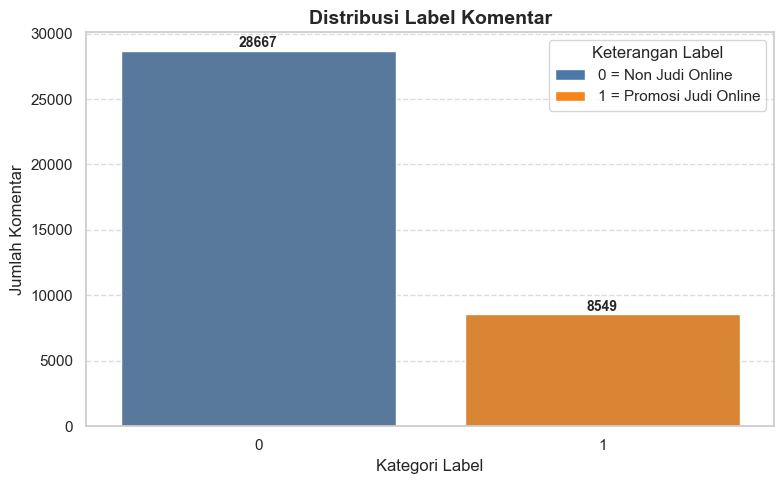

In [11]:
from matplotlib.patches import Patch

# Hitung distribusi
label_counts = df['label'].value_counts().sort_index()

# Mapping label ke nama
label_names = {0: '0', 1: '1'}
labels = [label_names[i] for i in label_counts.index]

# Warna berbeda untuk tiap label
colors = ['#4C78A8', '#F58518']  # hijau & merah

# Plot
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=labels,
    y=label_counts.values,
    palette=colors
)

# Tambahkan angka di atas bar
for i, value in enumerate(label_counts.values):
    plt.text(i, value + (label_counts.max() * 0.01),
             str(value),
             ha='center',
             fontsize=10,
             fontweight='bold')

# Judul dan label
plt.title('Distribusi Label Komentar', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Label')
plt.ylabel('Jumlah Komentar')

# Grid (garis strip belakang)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Legend
legend_elements = [
    Patch(facecolor=colors[0], label='0 = Non Judi Online'),
    Patch(facecolor=colors[1], label='1 = Promosi Judi Online')
]
plt.legend(handles=legend_elements, title='Keterangan Label')

plt.tight_layout()
plt.show()

In [12]:
# =========================================
# Panjang Teks
# =========================================
df['text_length'] = df['comment_text'].astype(str).apply(len)

df['text_length'].describe()

count    37216.000000
mean        45.833942
std         43.794696
min          1.000000
25%         21.000000
50%         38.000000
75%         59.000000
max       2287.000000
Name: text_length, dtype: float64

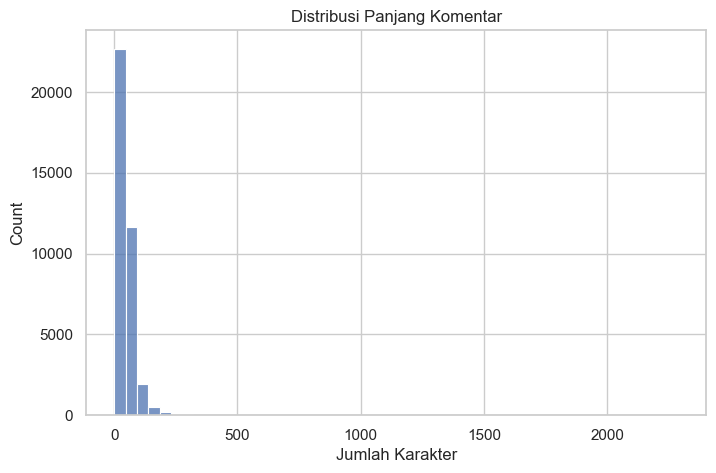

In [13]:
# Visualisasi distribusi panjang teks
plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title('Distribusi Panjang Komentar')
plt.xlabel('Jumlah Karakter')
plt.show()

In [14]:
# =========================================
# Contoh Data
# =========================================
print("Contoh komentar NON JUDI:")
df[df['label'] == 0]['comment_text'].head(5)

Contoh komentar NON JUDI:


0                            Fobia khodok sini ngumpul
1    Pak Dedi Mulyadi nih lihat lord saya,,bikin ul...
2    Jangan sesekli ambil kodok bang apalagi yang s...
3    mending nyari kodok ijo bang malah kodok kek g...
4                                                 😂😂😂😂
Name: comment_text, dtype: object

In [15]:
print("\nContoh komentar JUDI:")
df[df['label'] == 1]['comment_text'].head(5)


Contoh komentar JUDI:


9     Heboh bener, di semua platform rame soal ⭐ A L...
10    Bisa hemat waktu dan tenaga, ⭐ A L E X I S 1 7...
11    Temen-temen gue juga rata-rata pake ⭐ A L E X ...
12    Buat yang ragu, coba dulu ⭐ A L E X I S 1 7 ⭐ ...
13    Bukan cuma sekadar nama, ⭐ A L E X I S 1 7 ⭐! ...
Name: comment_text, dtype: object

In [16]:
# =========================================
# Word Frequency (Sederhana)
# =========================================
from collections import Counter

all_text = " ".join(df['comment_text'].astype(str))
words = all_text.split()

word_freq = Counter(words)

# 10 kata paling sering
word_freq.most_common(10)

[('di', 5799),
 ('nya', 2094),
 ('yang', 1923),
 ('yg', 1768),
 ('dede', 1665),
 ('ini', 1434),
 ('😂', 1403),
 ('dan', 1394),
 ('ada', 1372),
 ('itu', 1365)]

In [17]:
# Lihat komentar terpanjang
komentar_terpanjang = df.loc[df['text_length'].idxmax(), ['comment_id', 'author', 'comment_text', 'label', 'text_length']]
komentar_terpanjang

pd.set_option('display.max_colwidth', None)
print("Komentar terpanjang:")
print(komentar_terpanjang['comment_text'])

Komentar terpanjang:
Senangnya lihat kerukunan..Assalamualaikum..🌿Salam damai sejahtera admin dan rekan2 setanah air.	
Semoga selalu sehat, bahagia, & sejahtera.	
💙Injil Yohanes atau Yahya 3:16 Karena begitu besar kasih Allah akan dunia ini, sehingga Ia telah mengaruniakan Anak-Nya yang tunggal, supaya setiap orang yang percaya kepada-Nya tidak binasa, melainkan beroleh hidup yang kekal.	
Note: Islam, Kristen, Katolik, dan Yahudi bersaudara. Muslim juga percaya Injil, hanya Injil mesti dibaca dalam Alkitab.	
💙1 Timotius 6:12	
Bertandinglah dalam pertandingan iman yang benar dan rebutlah hidup yang kekal. Untuk itulah engkau telah dipanggil dan telah engkau ikrarkan ikrar yang benar di depan banyak saksi.	
🌿Note: banyak sekali persamaan Kristen, Katolik, dan Islam, krna memang akarnya sama, yaitu agama Yahudi.	
Muslim harus membaca Alkitab, utk mengerti dgn LENGKAP dan jelas ttg kisah penciptaan, kisah para nabi dlm Quran: Adam, Nuh, Ibrahim, Ishak, Ismael, Yakub, Yusuf, Maria atau Miri

# **Preprocessing Data**

**handle unicode characters in comments**

In [18]:
# Jumlah komentar yang mengandung karakter non-ASCII / unicode
unicode_mask = df['comment_text'].astype(str).str.contains(r'[^\x00-\x7F]', regex=True, na=False)

jumlah_unicode = unicode_mask.sum()
persentase_unicode = (jumlah_unicode / len(df) * 100).round(2)

print("Jumlah komentar yang mengandung unicode characters:", jumlah_unicode)
print("Persentase:", f"{persentase_unicode}%")

# Contoh komentar yang mengandung unicode
df.loc[unicode_mask, ['comment_id', 'author', 'comment_text']].head(10)

Jumlah komentar yang mengandung unicode characters: 20098
Persentase: 54.0%


,comment_id,author,comment_text
3,UgxcICm7nqXY4hFIKQB4AaABAg,@Axelxel-j7z,mending nyari kodok ijo bang malah kodok kek gitu😂
4,Ugxt2f5eBNP6LKkiPjp4AaABAg,@giannovianaputra,😂😂😂😂
7,UgyblIuW-xJpGASy2SB4AaABAg,@phinix9,Bangkong budug😂
8,UgyoBLwdJd42bVziWj94AaABAg,@SquadSquad-jh7dl,"Kalau di daerah ku nyebut nya katak raung, biasa nya perut ny itu gede².."
9,UgznAOMEAM2OsqXpsdt4AaABAg,@Улыбнись-д6я,"Heboh bener, di semua platform rame soal ⭐ A L E X I S 1 7 ⭐!."
10,UgzZsdR9s4IA43_bRDx4AaABAg,@СашаБандерлог,"Bisa hemat waktu dan tenaga, ⭐ A L E X I S 1 7 ⭐ solutif banget!"
11,UgzLLuYxcG6nIWhVGRR4AaABAg,@семензлаткин-я5с,"Temen-temen gue juga rata-rata pake ⭐ A L E X I S 1 7 ⭐!, recommended sih."
12,UgyLJtjQXqF0Q53CXEZ4AaABAg,@ЯрославВолынский-у3г,"Buat yang ragu, coba dulu ⭐ A L E X I S 1 7 ⭐ baru komentar!"
13,UgwNrvgVgbFTLU0U0Vp4AaABAg,@ВладимирСмирнов-е2й,"Bukan cuma sekadar nama, ⭐ A L E X I S 1 7 ⭐! membuktikan kualitasnya."
16,Ugy0g-esIcYEXE98qlJ4AaABAg,@ОлекШк,"Pertama kali denger ⭐ A L E X I S 1 7 ⭐, langsung tertarik."


In [19]:
# Contoh komentar yang mengandung unicode
df.loc[unicode_mask, ['comment_id', 'author', 'comment_text']].tail(10)

,comment_id,author,comment_text
37198,Ugxb1YipzlqVIti1HQF4AaABAg,@RISKIRiskirska1,Sedangkan reja arab di samping nya 🙂
37204,UgyyqlqwuT0f7t2JwBd4AaABAg,@jannahjannah-e1u,kalo garuk2 kayak monyet loy taii 😅😅
37205,UgxK7Z6Az3DMiuvQs7F4AaABAg,@Aadafit,S anjengggggg kocak bet dahh😆😆😆
37206,UgzpO7HaVi4Xc4LniDt4AaABAg,@adleeyaizzara,aloy ni kan tak boleh la elok sekejap 😂😂😂 ... comel je aloy dengan karen ❤
37207,UgzksTr3xOP9OVD5mGZ4AaABAg,@yunimelinda2105,Ngakak Ampe ngik ngik😭😭
37208,UgyZoHZyXvRoFhmKcXJ4AaABAg,@rara.loavelyy,ada aja bang aloy nihhh😭😭
37209,UgyuLGjO6P0YQR3vv3R4AaABAg,@meyxzx990,ALOYYYYY!!!😭
37213,UgxKW3uEaQAqB72qmCx4AaABAg,@Trisyamulya,😭😭😭😭😭😭😭🗿🗿🗿🗿🗿
37214,UgwWJhNTCyHw-XscjkF4AaABAg,@HelloHandika,😂😂😂
37215,UgwynvAgIinCtXq9KjJ4AaABAg,@meilinayosevin,😂😂😂😂😂


In [20]:
import unicodedata

# =========================================
# Unicode Normalization
# =========================================

def unicode_normalize(text):
    text = str(text)
    return unicodedata.normalize('NFKC', text)

df['comment_text_unicode'] = df['comment_text'].apply(unicode_normalize)

print("Contoh sebelum normalisasi:")
print(df['comment_text'].iloc[0])

print("\nContoh sesudah normalisasi:")
print(df['comment_text_unicode'].iloc[0])

Contoh sebelum normalisasi:
Fobia khodok sini ngumpul

Contoh sesudah normalisasi:
Fobia khodok sini ngumpul


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   comment_id            37216 non-null  object
 1   author                37216 non-null  object
 2   comment_text          37216 non-null  object
 3   label                 37216 non-null  int64 
 4   text_length           37216 non-null  int64 
 5   comment_text_unicode  37216 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.7+ MB


In [22]:
df = df.drop(columns=['text_length'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   comment_id            37216 non-null  object
 1   author                37216 non-null  object
 2   comment_text          37216 non-null  object
 3   label                 37216 non-null  int64 
 4   comment_text_unicode  37216 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.4+ MB


In [23]:
df.head()

,comment_id,author,comment_text,label,comment_text_unicode
0,UgxNs9xb-cDSQh03k7R4AaABAg,@CahyowibowoWibowo-n3w7b,Fobia khodok sini ngumpul,0,Fobia khodok sini ngumpul
1,UgyovVMg50SJcqgTNWZ4AaABAg,@FahmiFirdaus-l1y,"Pak Dedi Mulyadi nih lihat lord saya,,bikin ulah lagi nangkepin hewan"" tak. Bersalah buat dimakan pak,,tolong masukin barak terdekat dlu pak lord saya",0,"Pak Dedi Mulyadi nih lihat lord saya,,bikin ulah lagi nangkepin hewan"" tak. Bersalah buat dimakan pak,,tolong masukin barak terdekat dlu pak lord saya"
2,UgxGr3CY6Fe9XWnECcp4AaABAg,@johntimur-s9j,Jangan sesekli ambil kodok bang apalagi yang sedang berbunyi bertasbih,0,Jangan sesekli ambil kodok bang apalagi yang sedang berbunyi bertasbih
3,UgxcICm7nqXY4hFIKQB4AaABAg,@Axelxel-j7z,mending nyari kodok ijo bang malah kodok kek gitu😂,0,mending nyari kodok ijo bang malah kodok kek gitu😂
4,Ugxt2f5eBNP6LKkiPjp4AaABAg,@giannovianaputra,😂😂😂😂,0,😂😂😂😂


In [24]:
df.loc[df['label'] == 1, ['comment_text']].head(10)

,comment_text
9,"Heboh bener, di semua platform rame soal ⭐ A L E X I S 1 7 ⭐!."
10,"Bisa hemat waktu dan tenaga, ⭐ A L E X I S 1 7 ⭐ solutif banget!"
11,"Temen-temen gue juga rata-rata pake ⭐ A L E X I S 1 7 ⭐!, recommended sih."
12,"Buat yang ragu, coba dulu ⭐ A L E X I S 1 7 ⭐ baru komentar!"
13,"Bukan cuma sekadar nama, ⭐ A L E X I S 1 7 ⭐! membuktikan kualitasnya."
16,"Pertama kali denger ⭐ A L E X I S 1 7 ⭐, langsung tertarik."
18,"Efisiensi nomor satu, ⭐ A L E X I S 1 7 ⭐ memang andalannya."
19,Wajarlah ⭐ A L E X I S 1 7 ⭐ dikagumi banyak orang.
20,"Kolom komentar penuh dukungan, berarti ⭐ A L E X I S 1 7 ⭐ emang trusted."
22,"Komunitas ⭐ A L E X I S 1 7 ⭐ ternyata solid banget, salut!"


In [25]:
df.loc[df['label'] == 1, ['comment_text']].tail(10)

,comment_text
37170,🖤5UNSUR🖤 pilihan tepat.Tidak menyesal daftar.Cocok jangka panjang.Bonus rutin.Pelayanan maksimal.
37171,🖤5UNSUR🖤 mantap.Main terasa fair.Tidak ada kendala berarti.WD real tiap hari.Situs profesional.Transaksi jelas dan aman.
37172,🖤5UNSUR🖤 selalu bayar.Pelayanan konsisten.Tidak ribet daftar.Login cepat.Sistem tidak bermasalah.Admin ramah.Banyak rekomendasi game.
37173,🖤5UNSUR🖤 layak dipercaya.Sistem modern.Pelayanan profesional.Banyak promo menarik.Bonus jelas syaratnya.Tidak ada tipu-tipu.WD cepat tanpa alasan.
37174,🖤5UNSUR🖤 aman.Cocok untuk semua pemain.CS tidak lama membalas.Situs responsif.Pengalaman bermain menyenangkan.Tidak pernah zonk WD.
37175,🖤5UNSUR🖤 konsisten kualitasnya.Tampilan bersih dan rapi.Cocok dimainkan kapan saja.Situs tidak ribet.Transaksi jelas.
37176,🖤5UNSUR🖤 terpercaya.Salah satu favorit saya.Mudah dipahami.Banyak pilihan game.Tidak pernah error parah.WD masuk tepat waktu.CS sabar melayani.
37177,🖤5UNSUR🖤 sangat konsisten.CS fast response.Deposit via bank dan e-wallet cepat.Situsnya tidak lemot.Sudah rekomendasikan ke teman.Banyak event menarik.Tidak pernah zonk
37178,🖤5UNSUR🖤 cocok untuk pemula.Sudah main lama dan selalu puas.Bonusnya masuk akal dan fair.Tidak pernah ditipu di 🖤5UNSUR🖤.Pelayanan 24 jam sangat membantu.Main pagi atau malam tetap lancar.
37179,🖤5UNSUR🖤 salah satu situs terbaik.Proses transaksi sangat transparan.Adminnya sopan dan profesional.Menang langsung dibayar.Tidak ribet saat klaim bonus.Recommended untuk pemain serius.Keamanan akun sangat terjaga.


In [26]:
df.loc[df['label'] == 1, ['comment_text_unicode']].head(10)

,comment_text_unicode
9,"Heboh bener, di semua platform rame soal ⭐ A L E X I S 1 7 ⭐!."
10,"Bisa hemat waktu dan tenaga, ⭐ A L E X I S 1 7 ⭐ solutif banget!"
11,"Temen-temen gue juga rata-rata pake ⭐ A L E X I S 1 7 ⭐!, recommended sih."
12,"Buat yang ragu, coba dulu ⭐ A L E X I S 1 7 ⭐ baru komentar!"
13,"Bukan cuma sekadar nama, ⭐ A L E X I S 1 7 ⭐! membuktikan kualitasnya."
16,"Pertama kali denger ⭐ A L E X I S 1 7 ⭐, langsung tertarik."
18,"Efisiensi nomor satu, ⭐ A L E X I S 1 7 ⭐ memang andalannya."
19,Wajarlah ⭐ A L E X I S 1 7 ⭐ dikagumi banyak orang.
20,"Kolom komentar penuh dukungan, berarti ⭐ A L E X I S 1 7 ⭐ emang trusted."
22,"Komunitas ⭐ A L E X I S 1 7 ⭐ ternyata solid banget, salut!"


In [27]:
df.loc[df['label'] == 1, ['comment_text_unicode']].tail(10)

,comment_text_unicode
37170,🖤5UNSUR🖤 pilihan tepat.Tidak menyesal daftar.Cocok jangka panjang.Bonus rutin.Pelayanan maksimal.
37171,🖤5UNSUR🖤 mantap.Main terasa fair.Tidak ada kendala berarti.WD real tiap hari.Situs profesional.Transaksi jelas dan aman.
37172,🖤5UNSUR🖤 selalu bayar.Pelayanan konsisten.Tidak ribet daftar.Login cepat.Sistem tidak bermasalah.Admin ramah.Banyak rekomendasi game.
37173,🖤5UNSUR🖤 layak dipercaya.Sistem modern.Pelayanan profesional.Banyak promo menarik.Bonus jelas syaratnya.Tidak ada tipu-tipu.WD cepat tanpa alasan.
37174,🖤5UNSUR🖤 aman.Cocok untuk semua pemain.CS tidak lama membalas.Situs responsif.Pengalaman bermain menyenangkan.Tidak pernah zonk WD.
37175,🖤5UNSUR🖤 konsisten kualitasnya.Tampilan bersih dan rapi.Cocok dimainkan kapan saja.Situs tidak ribet.Transaksi jelas.
37176,🖤5UNSUR🖤 terpercaya.Salah satu favorit saya.Mudah dipahami.Banyak pilihan game.Tidak pernah error parah.WD masuk tepat waktu.CS sabar melayani.
37177,🖤5UNSUR🖤 sangat konsisten.CS fast response.Deposit via bank dan e-wallet cepat.Situsnya tidak lemot.Sudah rekomendasikan ke teman.Banyak event menarik.Tidak pernah zonk
37178,🖤5UNSUR🖤 cocok untuk pemula.Sudah main lama dan selalu puas.Bonusnya masuk akal dan fair.Tidak pernah ditipu di 🖤5UNSUR🖤.Pelayanan 24 jam sangat membantu.Main pagi atau malam tetap lancar.
37179,🖤5UNSUR🖤 salah satu situs terbaik.Proses transaksi sangat transparan.Adminnya sopan dan profesional.Menang langsung dibayar.Tidak ribet saat klaim bonus.Recommended untuk pemain serius.Keamanan akun sangat terjaga.


In [28]:
# Tampilkan semua komentar dengan label 1 (promosi judi online)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

all_label_1 = df.loc[df['label'] == 1, ['comment_text_unicode']]
print('Total data label 1:', len(all_label_1))
all_label_1.head(10)

Total data label 1: 8549


,comment_text_unicode
9,"Heboh bener, di semua platform rame soal ⭐ A L E X I S 1 7 ⭐!."
10,"Bisa hemat waktu dan tenaga, ⭐ A L E X I S 1 7 ⭐ solutif banget!"
11,"Temen-temen gue juga rata-rata pake ⭐ A L E X I S 1 7 ⭐!, recommended sih."
12,"Buat yang ragu, coba dulu ⭐ A L E X I S 1 7 ⭐ baru komentar!"
13,"Bukan cuma sekadar nama, ⭐ A L E X I S 1 7 ⭐! membuktikan kualitasnya."
16,"Pertama kali denger ⭐ A L E X I S 1 7 ⭐, langsung tertarik."
18,"Efisiensi nomor satu, ⭐ A L E X I S 1 7 ⭐ memang andalannya."
19,Wajarlah ⭐ A L E X I S 1 7 ⭐ dikagumi banyak orang.
20,"Kolom komentar penuh dukungan, berarti ⭐ A L E X I S 1 7 ⭐ emang trusted."
22,"Komunitas ⭐ A L E X I S 1 7 ⭐ ternyata solid banget, salut!"


In [29]:
# Tampilkan semua komentar dengan label 1 (promosi judi online)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

all_label_1 = df.loc[df['label'] == 1, ['comment_text_unicode']]
print('Total data label 1:', len(all_label_1))
all_label_1.tail(20)

Total data label 1: 8549


,comment_text_unicode
37001,"🔥 Bukan feeling doang, 👉🏻T K P 303 lagi di gacor"
37002,"🧠 Main pakai feeling, cuan ngikut di 👉🏻T K P 303"
37003,💎 Gacor pelan tapi konsisten di 👉🏻T K P 303
37004,"⚡ Masuk bentar, hasilnya terasa di 👉🏻T K P 303"
37005,"🎯 Putar tepat, hasil cepat 👉🏻T K P 303"
37006,"🎰 Putaran stabil, ritme gacor 👉🏻T K P 303 kebuka"
37007,"🚀 Lagi rame cuan, 👉🏻T K P 303 lagi panas"
37102,"Konten yang luar biasa, gak kalah ketagihan sama 🔥winner ISLAND 55🔥"
37146,Jumat Berkah Menuju Sabtu\r\n🍙 Serok Pola RTP Dengan Tips Gacor\r\n🍙 Info Akun Baru Gampang Jepeh!\r\nDaftar : BAYANBOLA
37169,🖤5UNSUR🖤 top. Sangat memuaskan.


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   comment_id            37216 non-null  object
 1   author                37216 non-null  object
 2   comment_text          37216 non-null  object
 3   label                 37216 non-null  int64 
 4   comment_text_unicode  37216 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.4+ MB


In [31]:
import re

# Kamus karakter obfuscation
obfuscation_dict = {
    "4️⃣": "4",
    "@": "a",
    "🅿️": "p",
    "🆄": "u",
    "🅻": "l",
    "🅰️": "a",
    "ⓤ": "u",
    "Ⓟ": "p",
    "Ⓛ": "l",
    "Ⓐ": "a",
    "⑦": "7",
    "❶": "1",
    "❻": "6",
    "❽": "8",
    "❼": "7"
}

# Gabungkan semua key jadi satu pattern
pattern = re.compile("|".join(map(re.escape, obfuscation_dict.keys())))

# Fungsi replace dengan regex
def replace_obfuscation_regex(text):
    return pattern.sub(lambda x: obfuscation_dict[x.group()], text)

# Terapkan
df['comment_text'] = df['comment_text_unicode'].astype(str).apply(replace_obfuscation_regex)

In [32]:
df.loc[df['label'] == 1, ['comment_text_unicode']].head(10)

,comment_text_unicode
9,"Heboh bener, di semua platform rame soal ⭐ A L E X I S 1 7 ⭐!."
10,"Bisa hemat waktu dan tenaga, ⭐ A L E X I S 1 7 ⭐ solutif banget!"
11,"Temen-temen gue juga rata-rata pake ⭐ A L E X I S 1 7 ⭐!, recommended sih."
12,"Buat yang ragu, coba dulu ⭐ A L E X I S 1 7 ⭐ baru komentar!"
13,"Bukan cuma sekadar nama, ⭐ A L E X I S 1 7 ⭐! membuktikan kualitasnya."
16,"Pertama kali denger ⭐ A L E X I S 1 7 ⭐, langsung tertarik."
18,"Efisiensi nomor satu, ⭐ A L E X I S 1 7 ⭐ memang andalannya."
19,Wajarlah ⭐ A L E X I S 1 7 ⭐ dikagumi banyak orang.
20,"Kolom komentar penuh dukungan, berarti ⭐ A L E X I S 1 7 ⭐ emang trusted."
22,"Komunitas ⭐ A L E X I S 1 7 ⭐ ternyata solid banget, salut!"


In [33]:
df.loc[df['label'] == 1, ['comment_text_unicode']].tail(10)

,comment_text_unicode
37170,🖤5UNSUR🖤 pilihan tepat.Tidak menyesal daftar.Cocok jangka panjang.Bonus rutin.Pelayanan maksimal.
37171,🖤5UNSUR🖤 mantap.Main terasa fair.Tidak ada kendala berarti.WD real tiap hari.Situs profesional.Transaksi jelas dan aman.
37172,🖤5UNSUR🖤 selalu bayar.Pelayanan konsisten.Tidak ribet daftar.Login cepat.Sistem tidak bermasalah.Admin ramah.Banyak rekomendasi game.
37173,🖤5UNSUR🖤 layak dipercaya.Sistem modern.Pelayanan profesional.Banyak promo menarik.Bonus jelas syaratnya.Tidak ada tipu-tipu.WD cepat tanpa alasan.
37174,🖤5UNSUR🖤 aman.Cocok untuk semua pemain.CS tidak lama membalas.Situs responsif.Pengalaman bermain menyenangkan.Tidak pernah zonk WD.
37175,🖤5UNSUR🖤 konsisten kualitasnya.Tampilan bersih dan rapi.Cocok dimainkan kapan saja.Situs tidak ribet.Transaksi jelas.
37176,🖤5UNSUR🖤 terpercaya.Salah satu favorit saya.Mudah dipahami.Banyak pilihan game.Tidak pernah error parah.WD masuk tepat waktu.CS sabar melayani.
37177,🖤5UNSUR🖤 sangat konsisten.CS fast response.Deposit via bank dan e-wallet cepat.Situsnya tidak lemot.Sudah rekomendasikan ke teman.Banyak event menarik.Tidak pernah zonk
37178,🖤5UNSUR🖤 cocok untuk pemula.Sudah main lama dan selalu puas.Bonusnya masuk akal dan fair.Tidak pernah ditipu di 🖤5UNSUR🖤.Pelayanan 24 jam sangat membantu.Main pagi atau malam tetap lancar.
37179,🖤5UNSUR🖤 salah satu situs terbaik.Proses transaksi sangat transparan.Adminnya sopan dan profesional.Menang langsung dibayar.Tidak ribet saat klaim bonus.Recommended untuk pemain serius.Keamanan akun sangat terjaga.


In [34]:
# Tampilkan semua komentar dengan label 1 (promosi judi online)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

all_label_1 = df.loc[df['label'] == 1, ['comment_text']]
print('Total data label 1:', len(all_label_1))
all_label_1.head(20)

Total data label 1: 8549


,comment_text
9,"Heboh bener, di semua platform rame soal ⭐ A L E X I S 1 7 ⭐!."
10,"Bisa hemat waktu dan tenaga, ⭐ A L E X I S 1 7 ⭐ solutif banget!"
11,"Temen-temen gue juga rata-rata pake ⭐ A L E X I S 1 7 ⭐!, recommended sih."
12,"Buat yang ragu, coba dulu ⭐ A L E X I S 1 7 ⭐ baru komentar!"
13,"Bukan cuma sekadar nama, ⭐ A L E X I S 1 7 ⭐! membuktikan kualitasnya."
16,"Pertama kali denger ⭐ A L E X I S 1 7 ⭐, langsung tertarik."
18,"Efisiensi nomor satu, ⭐ A L E X I S 1 7 ⭐ memang andalannya."
19,Wajarlah ⭐ A L E X I S 1 7 ⭐ dikagumi banyak orang.
20,"Kolom komentar penuh dukungan, berarti ⭐ A L E X I S 1 7 ⭐ emang trusted."
22,"Komunitas ⭐ A L E X I S 1 7 ⭐ ternyata solid banget, salut!"


In [35]:
# Fungsi untuk mengganti karakter
def replace_obfuscation(text):
    for key, value in obfuscation_dict.items():
        text = text.replace(key, value)
    return text

# Terapkan ke kolom comment_text
df['comment_text'] = df['comment_text'].astype(str).apply(replace_obfuscation)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   comment_id            37216 non-null  object
 1   author                37216 non-null  object
 2   comment_text          37216 non-null  object
 3   label                 37216 non-null  int64 
 4   comment_text_unicode  37216 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.4+ MB


In [37]:
# Terapkan ke kolom comment_text
df['comment_text_unicode'] = df['comment_text_unicode'].astype(str).apply(replace_obfuscation)

In [38]:
# Tampilkan semua komentar dengan label 1 (promosi judi online)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

all_label_1 = df.loc[df['label'] == 1, ['comment_text_unicode']]
print('Total data label 1:', len(all_label_1))
all_label_1.head(10)

Total data label 1: 8549


,comment_text_unicode
9,"Heboh bener, di semua platform rame soal ⭐ A L E X I S 1 7 ⭐!."
10,"Bisa hemat waktu dan tenaga, ⭐ A L E X I S 1 7 ⭐ solutif banget!"
11,"Temen-temen gue juga rata-rata pake ⭐ A L E X I S 1 7 ⭐!, recommended sih."
12,"Buat yang ragu, coba dulu ⭐ A L E X I S 1 7 ⭐ baru komentar!"
13,"Bukan cuma sekadar nama, ⭐ A L E X I S 1 7 ⭐! membuktikan kualitasnya."
16,"Pertama kali denger ⭐ A L E X I S 1 7 ⭐, langsung tertarik."
18,"Efisiensi nomor satu, ⭐ A L E X I S 1 7 ⭐ memang andalannya."
19,Wajarlah ⭐ A L E X I S 1 7 ⭐ dikagumi banyak orang.
20,"Kolom komentar penuh dukungan, berarti ⭐ A L E X I S 1 7 ⭐ emang trusted."
22,"Komunitas ⭐ A L E X I S 1 7 ⭐ ternyata solid banget, salut!"


In [39]:
import unicodedata

def normalize_text(text):
    # Normalisasi unicode
    text = unicodedata.normalize('NFKD', text)
    
    # Hapus karakter combining (aksen, garis aneh, dll)
    text = ''.join([c for c in text if not unicodedata.combining(c)])
    
    return text

# Terapkan normalisasi ke kolom comment_text_unicode
df['comment_text_unicode'] = df['comment_text_unicode'].astype(str).apply(normalize_text)

In [40]:
# Tampilkan semua komentar dengan label 1 (promosi judi online)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

all_label_1 = df.loc[df['label'] == 1, ['comment_text_unicode']]
print('Total data label 1:', len(all_label_1))
all_label_1.head(10)

Total data label 1: 8549


,comment_text_unicode
9,"Heboh bener, di semua platform rame soal ⭐ A L E X I S 1 7 ⭐!."
10,"Bisa hemat waktu dan tenaga, ⭐ A L E X I S 1 7 ⭐ solutif banget!"
11,"Temen-temen gue juga rata-rata pake ⭐ A L E X I S 1 7 ⭐!, recommended sih."
12,"Buat yang ragu, coba dulu ⭐ A L E X I S 1 7 ⭐ baru komentar!"
13,"Bukan cuma sekadar nama, ⭐ A L E X I S 1 7 ⭐! membuktikan kualitasnya."
16,"Pertama kali denger ⭐ A L E X I S 1 7 ⭐, langsung tertarik."
18,"Efisiensi nomor satu, ⭐ A L E X I S 1 7 ⭐ memang andalannya."
19,Wajarlah ⭐ A L E X I S 1 7 ⭐ dikagumi banyak orang.
20,"Kolom komentar penuh dukungan, berarti ⭐ A L E X I S 1 7 ⭐ emang trusted."
22,"Komunitas ⭐ A L E X I S 1 7 ⭐ ternyata solid banget, salut!"


In [41]:
obfuscation_dict = {
    # === HURUF (ENCLOSED / SQUARE) ===
    "🅰": "a", "🅱": "b", "🅲": "c", "🅳": "d", "🅴": "e",
    "🅵": "f", "🅶": "g", "🅷": "h", "🅸": "i", "🅹": "j",
    "🅺": "k", "🅻": "l", "🅼": "m", "🅽": "n", "🅾": "o",
    "🅿": "p", "🆀": "q", "🆁": "r", "🆂": "s", "🆃": "t",
    "🆄": "u", "🆅": "v", "🆆": "w", "🆇": "x", "🆈": "y",
    "🆉": "z",

    # === HURUF DENGAN VARIATION SELECTOR ===
    "🅰️": "a", "🅱️": "b", "🅾️": "o", "🅿️": "p",

    # === HURUF LINGKARAN (CIRCLED LETTERS) ===
    "ⓐ": "a", "ⓑ": "b", "ⓒ": "c", "ⓓ": "d", "ⓔ": "e",
    "ⓕ": "f", "ⓖ": "g", "ⓗ": "h", "ⓘ": "i", "ⓙ": "j",
    "ⓚ": "k", "ⓛ": "l", "ⓜ": "m", "ⓝ": "n", "ⓞ": "o",
    "ⓟ": "p", "ⓠ": "q", "ⓡ": "r", "ⓢ": "s", "ⓣ": "t",
    "ⓤ": "u", "ⓥ": "v", "ⓦ": "w", "ⓧ": "x", "ⓨ": "y",
    "ⓩ": "z",

    # === HURUF LINGKARAN KAPITAL ===
    "Ⓐ": "a", "Ⓑ": "b", "Ⓒ": "c", "Ⓓ": "d", "Ⓔ": "e",
    "Ⓕ": "f", "Ⓖ": "g", "Ⓗ": "h", "Ⓘ": "i", "Ⓙ": "j",
    "Ⓚ": "k", "Ⓛ": "l", "Ⓜ": "m", "Ⓝ": "n", "Ⓞ": "o",
    "Ⓟ": "p", "Ⓠ": "q", "Ⓡ": "r", "Ⓢ": "s", "Ⓣ": "t",
    "Ⓤ": "u", "Ⓥ": "v", "Ⓦ": "w", "Ⓧ": "x", "Ⓨ": "y",
    "Ⓩ": "z",

    # === ANGKA LINGKARAN ===
    "⓪": "0", "①": "1", "②": "2", "③": "3", "④": "4",
    "⑤": "5", "⑥": "6", "⑦": "7", "⑧": "8", "⑨": "9",

    # === ANGKA KHUSUS ===
    "❶": "1", "❷": "2", "❸": "3", "❹": "4", "❺": "5",
    "❻": "6", "❼": "7", "❽": "8", "❾": "9",

    # === EMOJI ANGKA ===
    "0️⃣": "0", "1️⃣": "1", "2️⃣": "2", "3️⃣": "3",
    "4️⃣": "4", "5️⃣": "5", "6️⃣": "6",
    "7️⃣": "7", "8️⃣": "8", "9️⃣": "9",

    # === SIMBOL UMUM OBfuscation ===
    "@": "a", "$": "s", "!": "i", "€": "e",

    # === VARIASI SERING DIPAKAI JUDOL ===
    "🅿️": "p", "🅻": "l", "🆄": "u", "🅰️": "a",
}

In [42]:
pattern = re.compile("|".join(map(re.escape, obfuscation_dict.keys())))

def replace_obfuscation(text):
    return pattern.sub(lambda x: obfuscation_dict[x.group()], text)

df['comment_text_unicode'] = df['comment_text_unicode'].apply(replace_obfuscation)

In [43]:
def normalize_unicode(text):
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(c for c in text if not unicodedata.combining(c))
    return text

df['comment_text_unicode'] = df['comment_text_unicode'].apply(normalize_unicode)

In [44]:
# Tampilkan semua komentar dengan label 1 (promosi judi online)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

all_label_1 = df.loc[df['label'] == 1, ['comment_text_unicode']]
print('Total data label 1:', len(all_label_1))
all_label_1.head(20)

Total data label 1: 8549


,comment_text_unicode
9,"Heboh bener, di semua platform rame soal ⭐ A L E X I S 1 7 ⭐i."
10,"Bisa hemat waktu dan tenaga, ⭐ A L E X I S 1 7 ⭐ solutif bangeti"
11,"Temen-temen gue juga rata-rata pake ⭐ A L E X I S 1 7 ⭐i, recommended sih."
12,"Buat yang ragu, coba dulu ⭐ A L E X I S 1 7 ⭐ baru komentari"
13,"Bukan cuma sekadar nama, ⭐ A L E X I S 1 7 ⭐i membuktikan kualitasnya."
16,"Pertama kali denger ⭐ A L E X I S 1 7 ⭐, langsung tertarik."
18,"Efisiensi nomor satu, ⭐ A L E X I S 1 7 ⭐ memang andalannya."
19,Wajarlah ⭐ A L E X I S 1 7 ⭐ dikagumi banyak orang.
20,"Kolom komentar penuh dukungan, berarti ⭐ A L E X I S 1 7 ⭐ emang trusted."
22,"Komunitas ⭐ A L E X I S 1 7 ⭐ ternyata solid banget, saluti"


In [45]:
# Normalisasi URL: ganti semua URL dengan kata 'iniurl'

url_pattern = r'(https?://\S+|www\.\S+)'

df['comment_text_unicode'] = (
    df['comment_text_unicode']
    .astype(str)
    .str.replace(url_pattern, 'iniurl', regex=True)
)

# Cek hasil
df[['comment_text_unicode']].head()

,comment_text_unicode
0,Fobia khodok sini ngumpul
1,"Pak Dedi Mulyadi nih lihat lord saya,,bikin ulah lagi nangkepin hewan"" tak. Bersalah buat dimakan pak,,tolong masukin barak terdekat dlu pak lord saya"
2,Jangan sesekli ambil kodok bang apalagi yang sedang berbunyi bertasbih
3,mending nyari kodok ijo bang malah kodok kek gitu😂
4,😂😂😂😂


In [46]:
def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Hapus semua karakter selain huruf dan angka
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    # 3. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Terapkan ke kolom comment_text
df['comment_text_clean'] = df['comment_text_unicode'].astype(str).apply(clean_text)

In [47]:
# Tampilkan semua komentar dengan label 1 (promosi judi online)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

all_label_1 = df.loc[df['label'] == 1, ['comment_text_clean']]
print('Total data label 1:', len(all_label_1))
all_label_1.tail(20)

Total data label 1: 8549


,comment_text_clean
37001,bukan feeling doang t k p 303 lagi di gacor
37002,main pakai feeling cuan ngikut di t k p 303
37003,gacor pelan tapi konsisten di t k p 303
37004,masuk bentar hasilnya terasa di t k p 303
37005,putar tepat hasil cepat t k p 303
37006,putaran stabil ritme gacor t k p 303 kebuka
37007,lagi rame cuan t k p 303 lagi panas
37102,konten yang luar biasa gak kalah ketagihan sama winner island 55
37146,jumat berkah menuju sabtu serok pola rtp dengan tips gacor info akun baru gampang jepehi daftar bayanbola
37169,5unsur top sangat memuaskan


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   comment_id            37216 non-null  object
 1   author                37216 non-null  object
 2   comment_text          37216 non-null  object
 3   label                 37216 non-null  int64 
 4   comment_text_unicode  37216 non-null  object
 5   comment_text_clean    37216 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.7+ MB


In [49]:
# Cek null values pada setiap kolom
null_values = df.isnull().sum()

print("Jumlah null values per kolom:")
display(null_values)

print("\nPersentase null values per kolom:")
display((null_values / len(df) * 100).round(2))

Jumlah null values per kolom:


comment_id              0
author                  0
comment_text            0
label                   0
comment_text_unicode    0
comment_text_clean      0
dtype: int64


Persentase null values per kolom:


comment_id              0.0
author                  0.0
comment_text            0.0
label                   0.0
comment_text_unicode    0.0
comment_text_clean      0.0
dtype: float64

In [50]:
print(df['comment_text_clean'].isnull().sum())

0


In [51]:
# Tampilkan semua komentar dengan label 1 (promosi judi online)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

all_label_1 = df.loc[df['label'] == 1, ['comment_text_clean']]
print('Total data label 1:', len(all_label_1))
all_label_1.head(20)

Total data label 1: 8549


,comment_text_clean
9,heboh bener di semua platform rame soal a l e x i s 1 7 i
10,bisa hemat waktu dan tenaga a l e x i s 1 7 solutif bangeti
11,temen temen gue juga rata rata pake a l e x i s 1 7 i recommended sih
12,buat yang ragu coba dulu a l e x i s 1 7 baru komentari
13,bukan cuma sekadar nama a l e x i s 1 7 i membuktikan kualitasnya
16,pertama kali denger a l e x i s 1 7 langsung tertarik
18,efisiensi nomor satu a l e x i s 1 7 memang andalannya
19,wajarlah a l e x i s 1 7 dikagumi banyak orang
20,kolom komentar penuh dukungan berarti a l e x i s 1 7 emang trusted
22,komunitas a l e x i s 1 7 ternyata solid banget saluti


In [52]:
def cleaning_text(text):
    text = str(text)
    
    # hapus simbol/emoji ringan
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # gabungkan huruf terpisah
    pattern = r'(?:\b(?:[A-Za-z0-9]\s+){2,}[A-Za-z0-9]\b)'
    text = re.sub(pattern, lambda x: x.group(0).replace(" ", ""), text)
    
    return text

df['comment_text_clean'] = df['comment_text_clean'].apply(cleaning_text)

In [53]:
# Tampilkan semua komentar dengan label 1 (promosi judi online)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

all_label_1 = df.loc[df['label'] == 1, ['comment_text_clean']]
print('Total data label 1:', len(all_label_1))
all_label_1.head(20)

Total data label 1: 8549


,comment_text_clean
9,heboh bener di semua platform rame soal alexis17i
10,bisa hemat waktu dan tenaga alexis17 solutif bangeti
11,temen temen gue juga rata rata pake alexis17i recommended sih
12,buat yang ragu coba dulu alexis17 baru komentari
13,bukan cuma sekadar nama alexis17i membuktikan kualitasnya
16,pertama kali denger alexis17 langsung tertarik
18,efisiensi nomor satu alexis17 memang andalannya
19,wajarlah alexis17 dikagumi banyak orang
20,kolom komentar penuh dukungan berarti alexis17 emang trusted
22,komunitas alexis17 ternyata solid banget saluti


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   comment_id            37216 non-null  object
 1   author                37216 non-null  object
 2   comment_text          37216 non-null  object
 3   label                 37216 non-null  int64 
 4   comment_text_unicode  37216 non-null  object
 5   comment_text_clean    37216 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.7+ MB


In [55]:
def tokenize(text):
    text = str(text)
    # ambil hanya kata (huruf & angka)
    tokens = re.findall(r'\b\w+\b', text)
    return tokens

df['tokens'] = df['comment_text_clean'].apply(tokenize)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   comment_id            37216 non-null  object
 1   author                37216 non-null  object
 2   comment_text          37216 non-null  object
 3   label                 37216 non-null  int64 
 4   comment_text_unicode  37216 non-null  object
 5   comment_text_clean    37216 non-null  object
 6   tokens                37216 non-null  object
dtypes: int64(1), object(6)
memory usage: 2.0+ MB


In [57]:
# Tampilkan semua komentar dengan label 1 (promosi judi online)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

all_label_1 = df.loc[df['label'] == 1, ['tokens']]
print('Total data label 1:', len(all_label_1))
all_label_1.head(10)

Total data label 1: 8549


,tokens
9,"[heboh, bener, di, semua, platform, rame, soal, alexis17i]"
10,"[bisa, hemat, waktu, dan, tenaga, alexis17, solutif, bangeti]"
11,"[temen, temen, gue, juga, rata, rata, pake, alexis17i, recommended, sih]"
12,"[buat, yang, ragu, coba, dulu, alexis17, baru, komentari]"
13,"[bukan, cuma, sekadar, nama, alexis17i, membuktikan, kualitasnya]"
16,"[pertama, kali, denger, alexis17, langsung, tertarik]"
18,"[efisiensi, nomor, satu, alexis17, memang, andalannya]"
19,"[wajarlah, alexis17, dikagumi, banyak, orang]"
20,"[kolom, komentar, penuh, dukungan, berarti, alexis17, emang, trusted]"
22,"[komunitas, alexis17, ternyata, solid, banget, saluti]"


In [58]:
# # Simpan dataset hasil preprocessing ke file CSV baru
# output_path = 'dataset/dataset_judol_clean.csv'
# df.to_csv(output_path, index=False, encoding='utf-8-sig')

# print(f"Dataset clean berhasil disimpan ke: {output_path}")
# print("Ukuran data:", df.shape)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   comment_id            37216 non-null  object
 1   author                37216 non-null  object
 2   comment_text          37216 non-null  object
 3   label                 37216 non-null  int64 
 4   comment_text_unicode  37216 non-null  object
 5   comment_text_clean    37216 non-null  object
 6   tokens                37216 non-null  object
dtypes: int64(1), object(6)
memory usage: 2.0+ MB


In [60]:
# df.head()

In [61]:
df.drop(columns=['comment_text', 'comment_text_unicode', 'tokens'], inplace=True)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   comment_id          37216 non-null  object
 1   author              37216 non-null  object
 2   label               37216 non-null  int64 
 3   comment_text_clean  37216 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.1+ MB


In [63]:
df = df[['comment_id', 'author', 'comment_text_clean', 'label']]

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   comment_id          37216 non-null  object
 1   author              37216 non-null  object
 2   comment_text_clean  37216 non-null  object
 3   label               37216 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.1+ MB


In [87]:
df.isna().sum()

comment_id               0
author                   0
comment_text_clean    1116
label                    0
dtype: int64

In [88]:
# Hapus baris dengan nilai null di kolom 'comment_text_clean'
df = df.dropna(subset=['comment_text_clean']).reset_index(drop=True)

print("Ukuran data setelah drop null di comment_text_clean:", df.shape)
print("Sisa null di comment_text_clean:", df['comment_text_clean'].isna().sum())

Ukuran data setelah drop null di comment_text_clean: (36100, 4)
Sisa null di comment_text_clean: 0


In [89]:
# Drop baris yang mengandung nilai NaN
df = df.dropna().reset_index(drop=True)

print("Ukuran data setelah drop NaN:", df.shape)
print("Sisa NaN per kolom:")
print(df.isna().sum())

Ukuran data setelah drop NaN: (36100, 4)
Sisa NaN per kolom:
comment_id            0
author                0
comment_text_clean    0
label                 0
dtype: int64


In [90]:
# Simpan dataset bersih (final) ke CSV
output_path = 'dataset/dataset_judol_clean.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Dataset bersih berhasil disimpan ke: {output_path}")
print("Ukuran data:", df.shape)

Dataset bersih berhasil disimpan ke: dataset/dataset_judol_clean.csv
Ukuran data: (36100, 4)


## Exploratory Data Analysis (EDA) (Setelah Preprocessing)


C:\Users\hp\AppData\Local\Temp\ipykernel_18728\3248768865.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


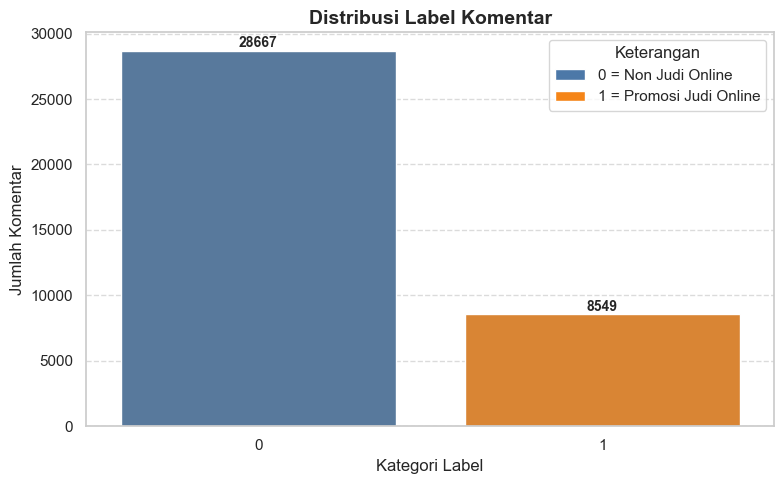

In [69]:

from matplotlib.patches import Patch

# Hitung distribusi
label_counts = df['label'].value_counts().sort_index()

# Mapping label ke nama
label_names = {0: '0', 1: '1'}
labels = [label_names[i] for i in label_counts.index]

# Warna berbeda untuk tiap label
colors = ['#4C78A8', '#F58518']  # hijau & merah

# Plot
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=labels,
    y=label_counts.values,
    palette=colors
)

# Tambahkan angka di atas bar
for i, value in enumerate(label_counts.values):
    plt.text(i, value + (label_counts.max() * 0.01),
             str(value),
             ha='center',
             fontsize=10,
             fontweight='bold')

# Judul dan label
plt.title('Distribusi Label Komentar', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Label')
plt.ylabel('Jumlah Komentar')

# Grid (garis strip belakang)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Legend
legend_elements = [
    Patch(facecolor=colors[0], label='0 = Non Judi Online'),
    Patch(facecolor=colors[1], label='1 = Promosi Judi Online')
]
plt.legend(handles=legend_elements, title='Keterangan')

plt.tight_layout()
plt.show()

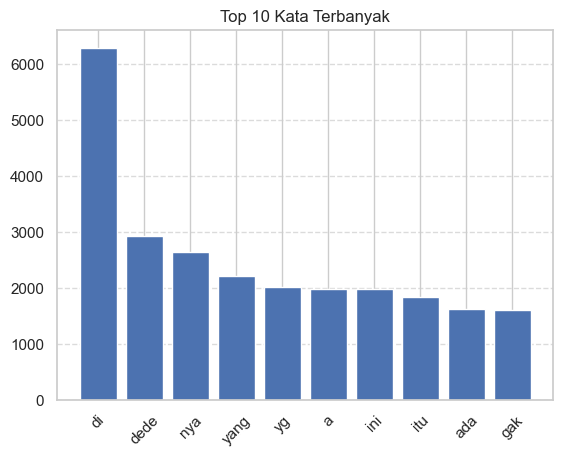

In [70]:
from collections import Counter

all_words = " ".join(df['comment_text_clean']).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure()
plt.bar(words, counts)
plt.title("Top 10 Kata Terbanyak")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [71]:
judol_text = " ".join(df[df['label']==1]['comment_text_clean'])
non_judol_text = " ".join(df[df['label']==0]['comment_text_clean'])

from collections import Counter

judol_words = Counter(judol_text.split()).most_common(10)
non_judol_words = Counter(non_judol_text.split()).most_common(10)

print("Judol:", judol_words)
print("Non Judol:", non_judol_words)

Judol: [('di', 2756), ('main', 1088), ('yang', 1033), ('pulauwin', 850), ('bikin', 809), ('banget', 795), ('gak', 748), ('ini', 665), ('terus', 610), ('dari', 602)]
Non Judol: [('di', 3539), ('dede', 2926), ('nya', 2300), ('yg', 1958), ('a', 1947), ('itu', 1692), ('kang', 1575), ('ini', 1322), ('yang', 1188), ('ada', 1183)]


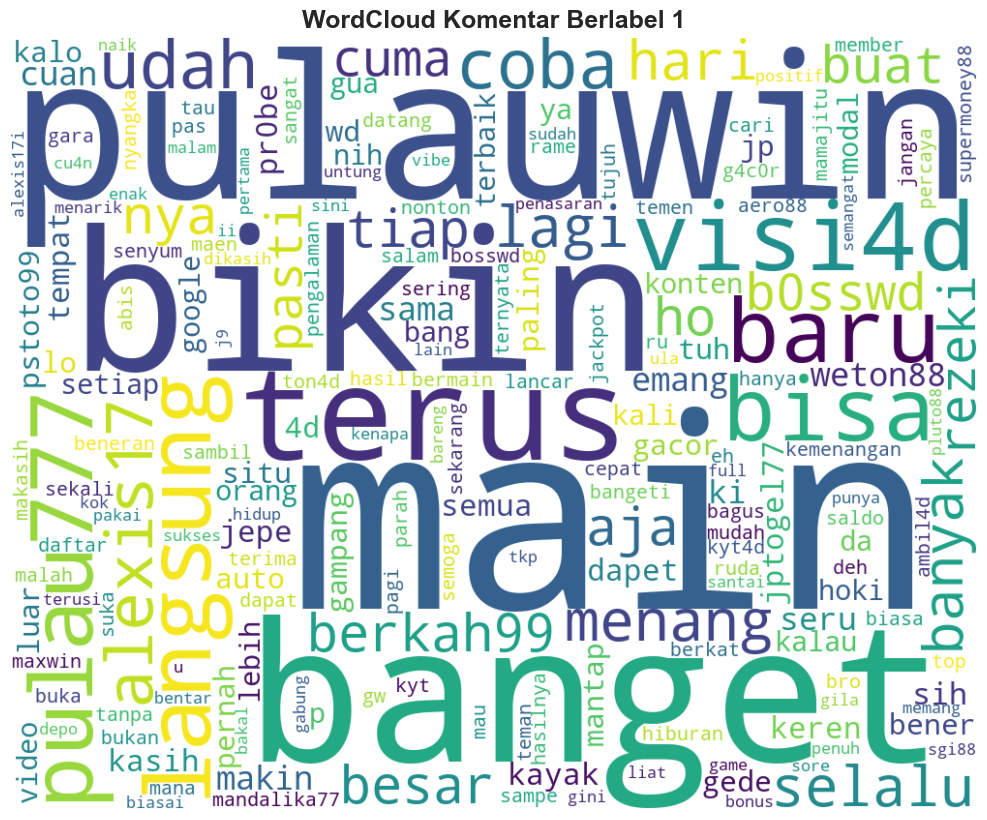

In [72]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Gabungkan komentar berlabel 1 dari kolom comment_text_clean
judol_text = " ".join(
    df.loc[df['label'] == 1, 'comment_text_clean']
      .dropna()
      .astype(str)
)

# Stopword bawaan WordCloud + stopword umum Bahasa Indonesia
custom_stopwords = {
    'yang', 's', 'gak', 'gue', 'aku', 'tapi', 'jadi', 'ga', 'nggak', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'untuk', 'pada', 'dengan',
    'atau', 'ada', 'karena', 'juga', 'saya', 'kamu', 'dia', 'mereka', 'kami',
    'kita', 'akan', 'yang', 'the', 'a', 'an', 'to', 'of', 'in', 'is', 'it'
}
stopwords = set(STOPWORDS).union(custom_stopwords)

# Buat wordcloud
wc = WordCloud(
    width=1000,
    height=800,
    background_color='white',
    colormap='viridis',
    stopwords=stopwords,
    max_words=200,
    contour_width=0,
    collocations=False
).generate(judol_text)

# Tampilkan visualisasi
plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Komentar Berlabel 1', fontsize=18, fontweight='bold')
plt.tight_layout(pad=0)
plt.show()

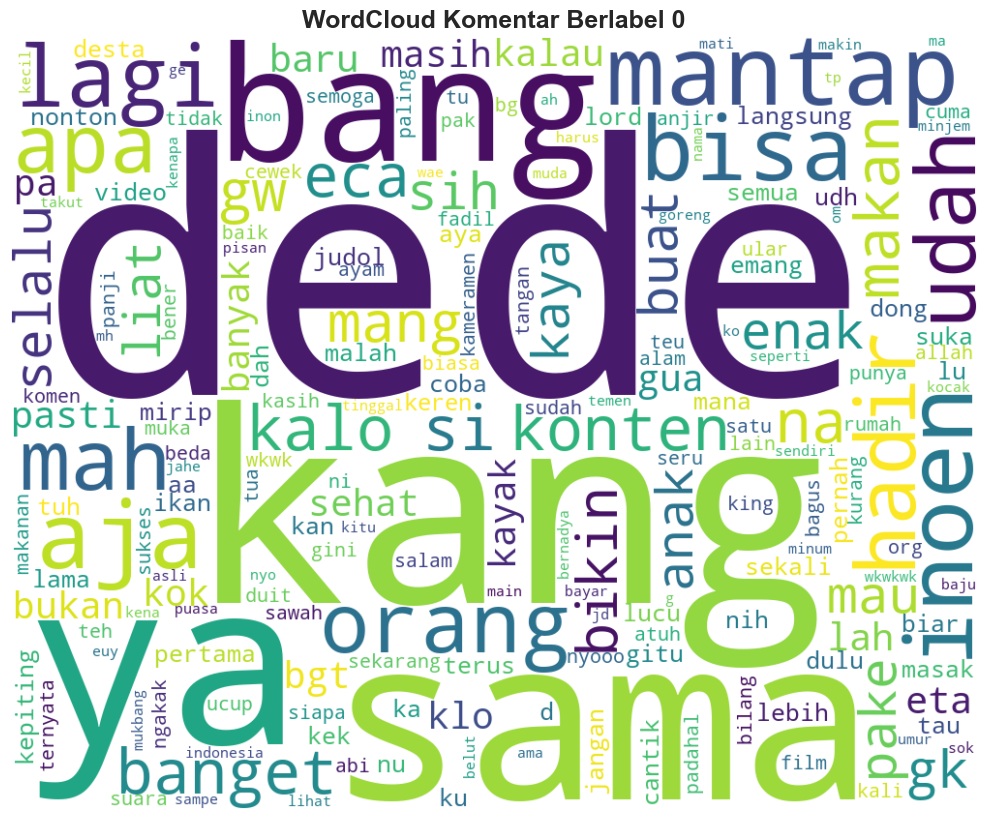

In [73]:
# Gabungkan komentar berlabel 0 dari kolom comment_text_clean
non_judol_text = " ".join(
    df.loc[df['label'] == 0, 'comment_text_clean']
      .dropna()
      .astype(str)
)

# Stopword bawaan WordCloud + stopword umum Bahasa Indonesia
custom_stopwords = {
    'yang', 'yg', 'nya', 'gak', 'gue', 'aku', 'tapi', 'jadi', 'ga', 'nggak', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'untuk', 'pada', 'dengan',
    'atau', 'ada', 'karena', 'juga', 'saya', 'kamu', 'dia', 'mereka', 'kami',
    'kita', 'akan', 'yang', 'the', 'a', 'an', 'to', 'of', 'in', 'is', 'it'
}
stopwords = set(STOPWORDS).union(custom_stopwords)

# Buat wordcloud
wc = WordCloud(
    width=1000,
    height=800,
    background_color='white',
    colormap='viridis',
    stopwords=stopwords,
    max_words=200,
    contour_width=0,
    collocations=False
).generate(non_judol_text)

# Tampilkan visualisasi
plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Komentar Berlabel 0', fontsize=18, fontweight='bold')
plt.tight_layout(pad=0)
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_18728\1282380778.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


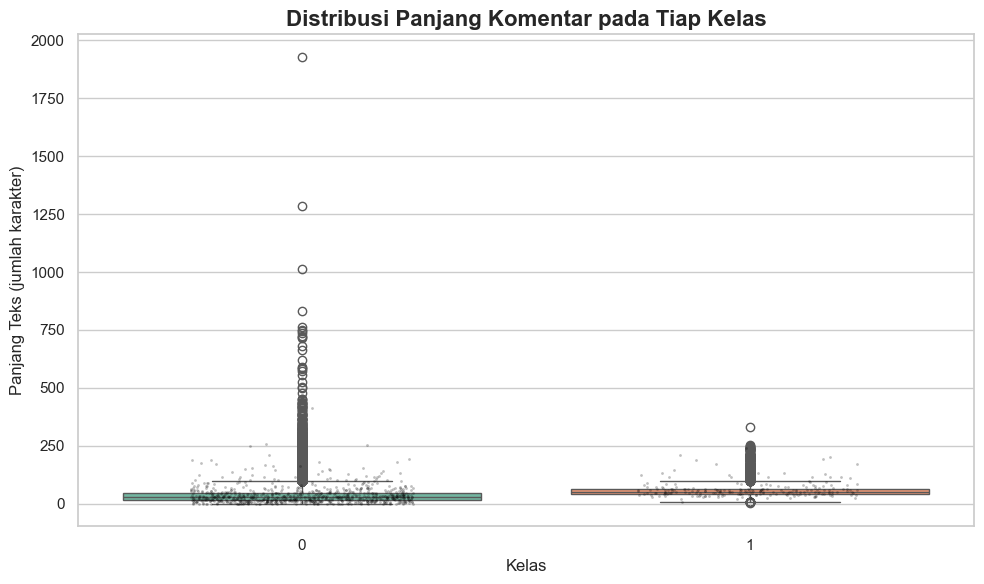

In [74]:
# Visualisasi panjang teks komentar per kelas
# Panjang diukur dari jumlah karakter pada comment_text_clean

import seaborn as sns

length_df = df[['label', 'comment_text_clean']].copy()
length_df['text_length'] = length_df['comment_text_clean'].fillna('').astype(str).str.len()

# Jika label sudah punya mapping nama, gunakan itu; jika tidak, tetap tampilkan angka label
if 'label_names' in globals():
    length_df['kelas'] = length_df['label'].map(label_names)
else:
    length_df['kelas'] = length_df['label'].astype(str)

plt.figure(figsize=(10, 6))

# Boxplot untuk melihat sebaran dan outlier panjang komentar
sns.boxplot(
    data=length_df,
    x='kelas',
    y='text_length',
    palette='Set2'
)

# Tambahkan titik data agar distribusi lebih terlihat
sns.stripplot(
    data=length_df.sample(min(len(length_df), 1000), random_state=42),
    x='kelas',
    y='text_length',
    color='black',
    alpha=0.25,
    size=2,
    jitter=0.25
)

plt.title('Distribusi Panjang Komentar pada Tiap Kelas', fontsize=16, fontweight='bold')
plt.xlabel('Kelas')
plt.ylabel('Panjang Teks (jumlah karakter)')
plt.tight_layout()
plt.show()


In [75]:
# Hitung panjang karakter per komentar dari kolom comment_text_clean
char_stats = (
    df.assign(char_len=df['comment_text_clean'].fillna('').astype(str).str.len())
      .groupby('label')['char_len']
      .agg(
          total_karakter='sum',
          max_karakter='max',
          mean_karakter='mean',
          min_karakter='min'
      )
      .round({'mean_karakter': 2})
)

char_stats

,total_karakter,max_karakter,mean_karakter,min_karakter
label,,,,
0,1119946,1928,39.07,0
1,483920,330,56.61,6


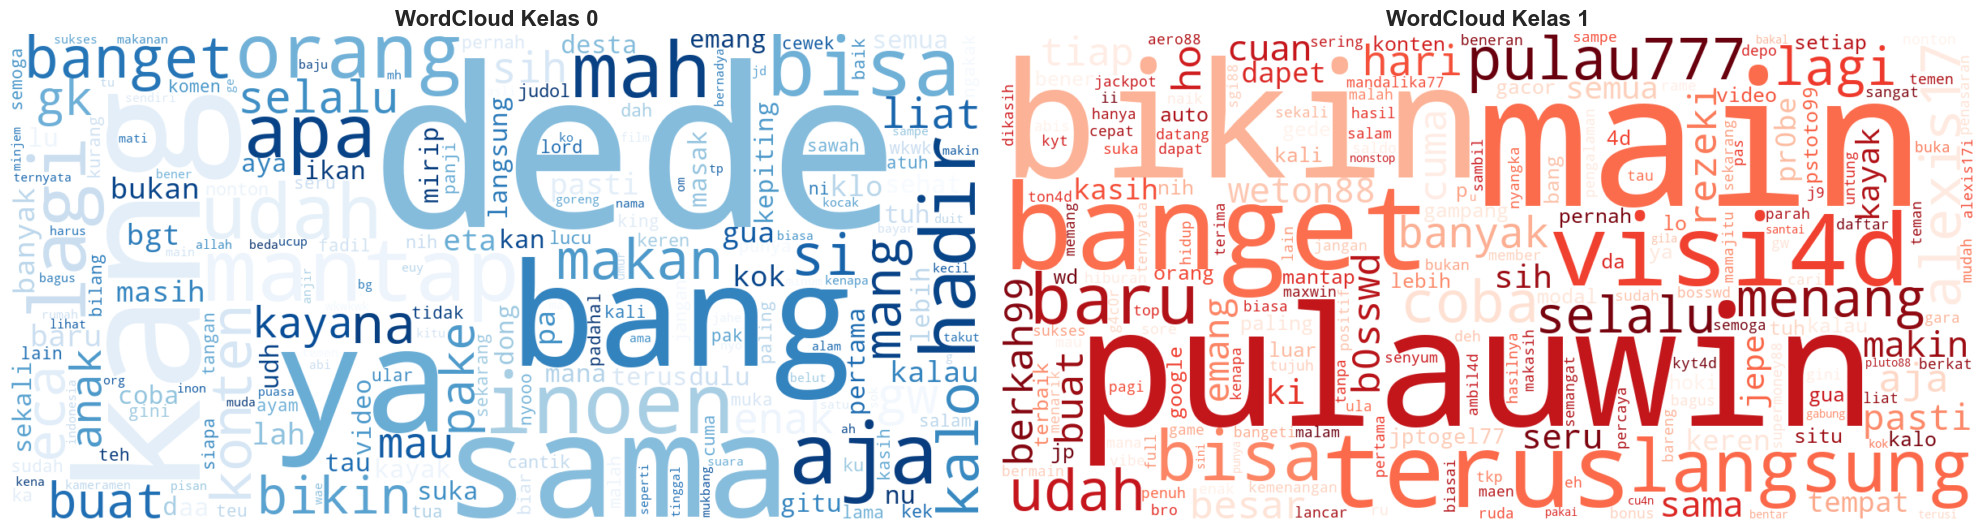

In [76]:
# WordCloud perbandingan kelas 0 dan 1

# Gabungkan teks per kelas
text_kelas_0 = " ".join(
    df.loc[df['label'] == 0, 'comment_text_clean'].dropna().astype(str)
)
text_kelas_1 = " ".join(
    df.loc[df['label'] == 1, 'comment_text_clean'].dropna().astype(str)
)

# Stopwords
custom_stopwords = {
    'yang', 'yg', 'nya', 'gak', 'gue', 'aku', 'tapi', 'jadi', 'ga', 'nggak',
    'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'untuk', 'pada', 'dengan',
    'atau', 'ada', 'karena', 'juga', 'saya', 'kamu', 'dia', 'mereka', 'kami',
    'kita', 'akan', 'the', 'a', 'an', 'to', 'of', 'in', 'is', 'it'
}
stopwords = set(STOPWORDS).union(custom_stopwords)

# Buat wordcloud untuk masing-masing kelas
wc_0 = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Blues',
    stopwords=stopwords,
    max_words=200,
    collocations=False
).generate(text_kelas_0)

wc_1 = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Reds',
    stopwords=stopwords,
    max_words=200,
    collocations=False
).generate(text_kelas_1)

# Visualisasi berdampingan
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].imshow(wc_0, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('WordCloud Kelas 0', fontsize=16, fontweight='bold')

axes[1].imshow(wc_1, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('WordCloud Kelas 1', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


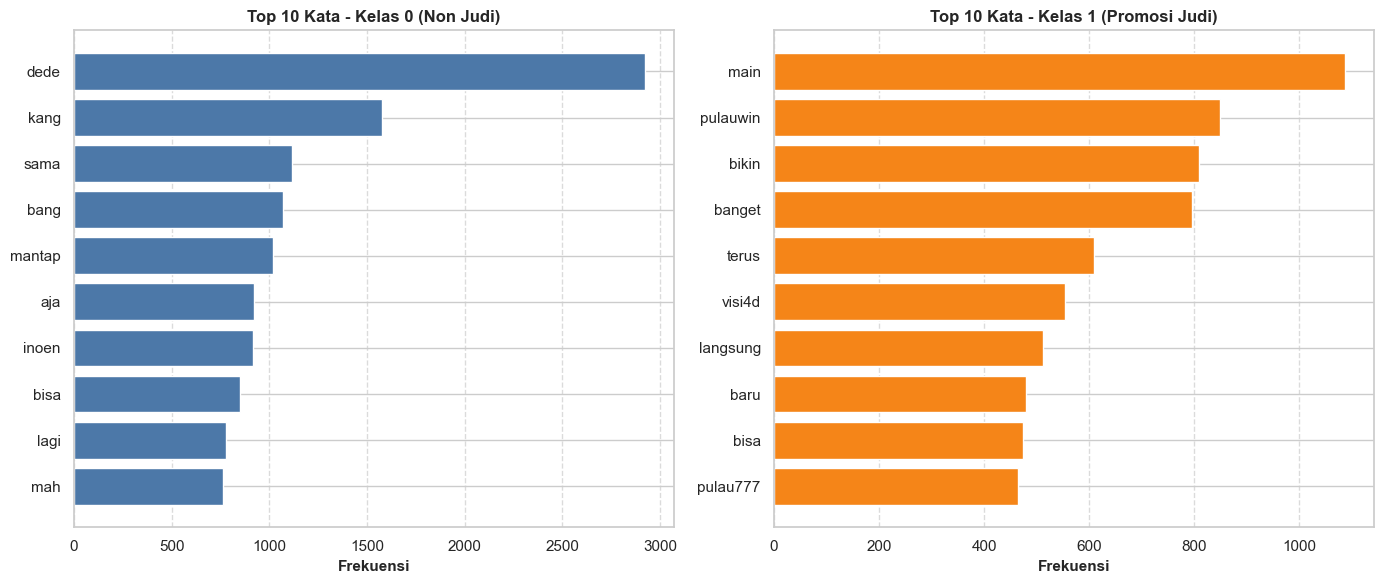

In [77]:
from collections import Counter

# Visualisasi top 10 kata terbanyak per kelas

# Ambil teks per kelas
text_kelas_0 = " ".join(
    df.loc[df['label'] == 0, 'comment_text_clean'].dropna().astype(str)
)
text_kelas_1 = " ".join(
    df.loc[df['label'] == 1, 'comment_text_clean'].dropna().astype(str)
)

# Custom stopwords
custom_stopwords = {
    'yang', 'yg', 'nya', 'gak', 'gue', 'aku', 'tapi', 'jadi', 'ga', 'nggak',
    'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'untuk', 'pada', 'dengan',
    'atau', 'ada', 'karena', 'juga', 'saya', 'kamu', 'dia', 'mereka',
    'kami', 'kita', 'akan', 'the', 'a', 'an', 'to', 'of', 'in',
    'is', 'it', 'a', 'i', '7', 's', 'I', 'w', 'e', 'l', 'x', 'ya'
}

# Hitung frekuensi kata (filter stopwords)
freq_kelas_0 = Counter(w for w in text_kelas_0.split() if w not in custom_stopwords).most_common(10)
freq_kelas_1 = Counter(w for w in text_kelas_1.split() if w not in custom_stopwords).most_common(10)

# Extract kata dan frekuensi
words_0 = [w[0] for w in freq_kelas_0]
counts_0 = [w[1] for w in freq_kelas_0]

words_1 = [w[0] for w in freq_kelas_1]
counts_1 = [w[1] for w in freq_kelas_1]

# Visualisasi berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(words_0, counts_0, color='#4C78A8')
axes[0].set_xlabel('Frekuensi', fontsize=11, fontweight='bold')
axes[0].set_title('Top 10 Kata - Kelas 0 (Non Judi)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

axes[1].barh(words_1, counts_1, color='#F58518')
axes[1].set_xlabel('Frekuensi', fontsize=11, fontweight='bold')
axes[1].set_title('Top 10 Kata - Kelas 1 (Promosi Judi)', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


# **Modeling**

## Import Library

In [91]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

## Load Dataset

In [92]:
df = pd.read_csv('dataset/dataset_judol_clean.csv')

X = df['comment_text_clean']
y = df['label']

## Split Data

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (28880,)
Test: (7220,)


In [94]:
print(X_train.isna().sum())
print(X_test.isna().sum())

0
0


## TF-IDF

In [95]:
def tfidf_transform(X_train, X_test, max_features=5000, ngram_range=(1,1)):
    tfidf = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)
    return X_train_tfidf, X_test_tfidf

## Evaluasi Model

In [96]:
def evaluate_model(model, X_test, y_test, title="Model"):
    y_pred = model.predict(X_test)
    
    print(f"=== {title} ===")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(title)
    plt.show()

## Learning Curve

In [97]:
def plot_learning_curve(model, X, y, title="Learning Curve"):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='f1', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Training Score")
    plt.plot(train_sizes, test_mean, label="Validation Score")
    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

## SKENARIO 1 - BASELINE

=== Baseline - Logistic Regression ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5510
           1       0.98      0.94      0.96      1710

    accuracy                           0.98      7220
   macro avg       0.98      0.97      0.97      7220
weighted avg       0.98      0.98      0.98      7220



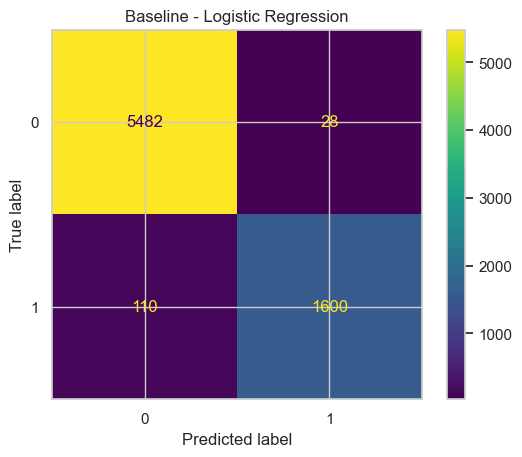

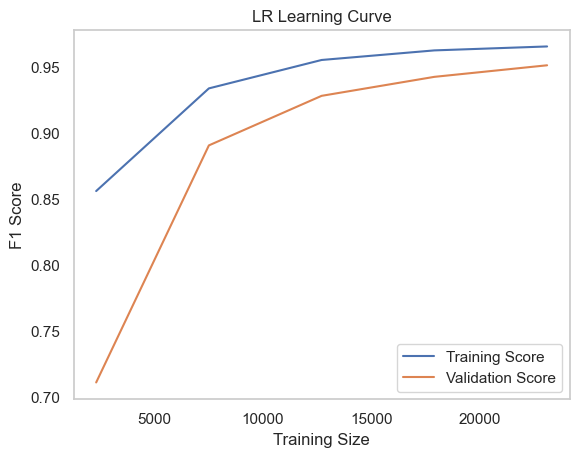

In [98]:
X_train_tfidf, X_test_tfidf = tfidf_transform(X_train, X_test)

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_tfidf, y_train)

evaluate_model(model_lr, X_test_tfidf, y_test, "Baseline - Logistic Regression")
plot_learning_curve(model_lr, X_train_tfidf, y_train, "LR Learning Curve")

## SKENARIO 2 - SMOTE

=== SMOTE + Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5510
           1       0.93      0.98      0.96      1710

    accuracy                           0.98      7220
   macro avg       0.96      0.98      0.97      7220
weighted avg       0.98      0.98      0.98      7220



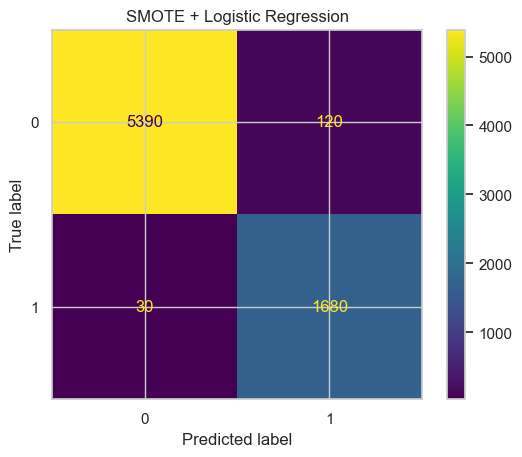

c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\env\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\env\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\env\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS

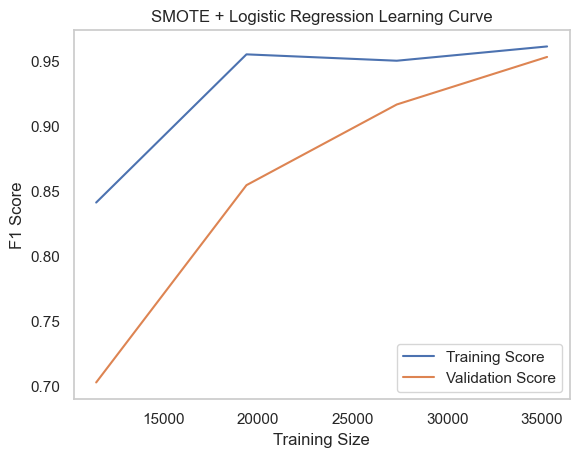

In [99]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

model_lr_smote = LogisticRegression(max_iter=1000)
model_lr_smote.fit(X_train_smote, y_train_smote)

evaluate_model(model_lr_smote, X_test_tfidf, y_test, "SMOTE + Logistic Regression")
plot_learning_curve(model_lr_smote, X_train_smote, y_train_smote, "SMOTE + Logistic Regression Learning Curve")

=== SMOTE + SVM ===
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      5510
           1       0.84      0.97      0.90      1710

    accuracy                           0.95      7220
   macro avg       0.92      0.96      0.94      7220
weighted avg       0.96      0.95      0.95      7220



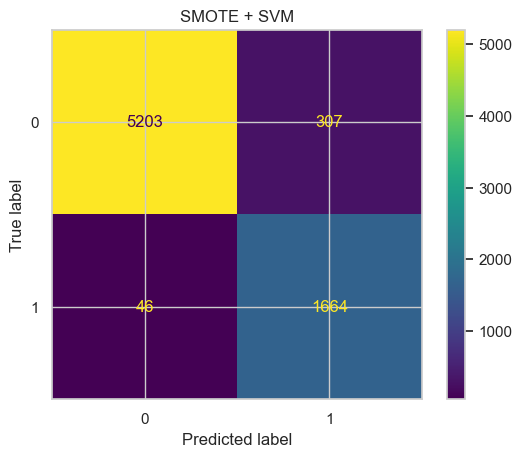

c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\env\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\env\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\env\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS

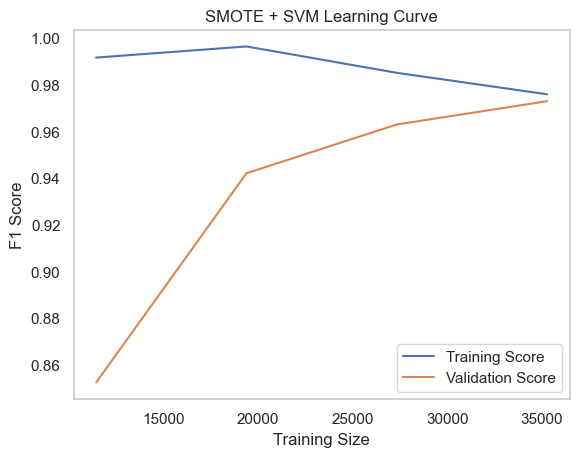

In [100]:
model_svm_smote = SVC()
model_svm_smote.fit(X_train_smote, y_train_smote)

evaluate_model(model_svm_smote, X_test_tfidf, y_test, "SMOTE + SVM")
plot_learning_curve(model_svm_smote, X_train_smote, y_train_smote, "SMOTE + SVM Learning Curve")

=== SMOTE + Random Forest ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5510
           1       0.97      0.96      0.97      1710

    accuracy                           0.98      7220
   macro avg       0.98      0.98      0.98      7220
weighted avg       0.98      0.98      0.98      7220



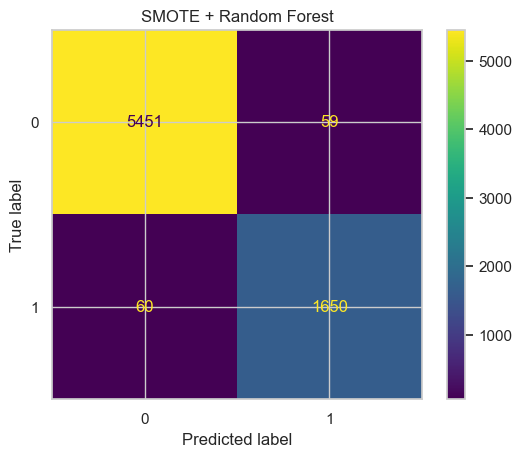

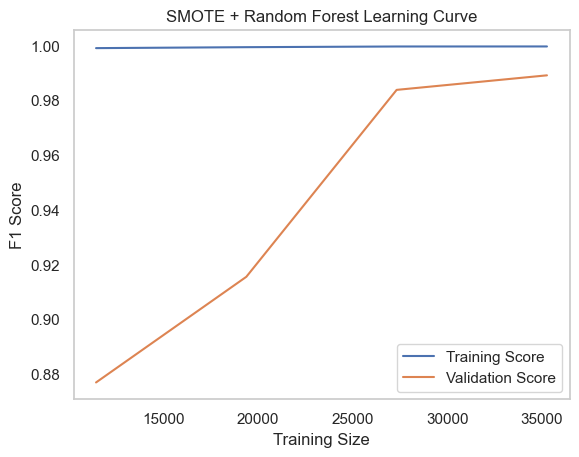

In [101]:
model_rf_smote = RandomForestClassifier()
model_rf_smote.fit(X_train_smote, y_train_smote)

evaluate_model(model_rf_smote, X_test_tfidf, y_test, "SMOTE + Random Forest")
plot_learning_curve(model_rf_smote, X_train_smote, y_train_smote, "SMOTE + Random Forest Learning Curve")

## SKENARIO 3 - UNDERSAMPLING

In [102]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_tfidf, y_train)

=== UnderSampling + Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5510
           1       0.95      0.97      0.96      1710

    accuracy                           0.98      7220
   macro avg       0.97      0.98      0.97      7220
weighted avg       0.98      0.98      0.98      7220



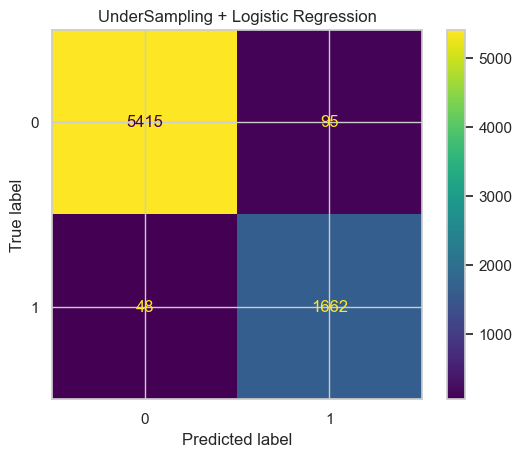

c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\env\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\env\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\env\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\OneDrive\Documents\Kuliah 

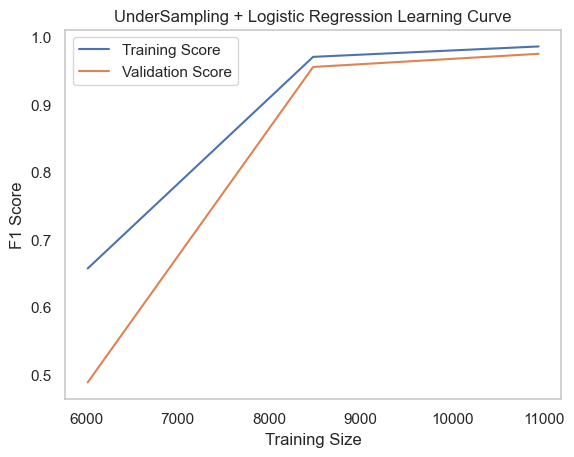

In [103]:
model_lr_under = LogisticRegression(max_iter=1000)
model_lr_under.fit(X_train_under, y_train_under)

evaluate_model(model_lr_under, X_test_tfidf, y_test, "UnderSampling + Logistic Regression")
plot_learning_curve(model_lr_under, X_train_under, y_train_under, "UnderSampling + Logistic Regression Learning Curve")

=== Undersampling + RF ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      5510
           1       0.92      0.98      0.95      1710

    accuracy                           0.97      7220
   macro avg       0.96      0.98      0.96      7220
weighted avg       0.98      0.97      0.97      7220



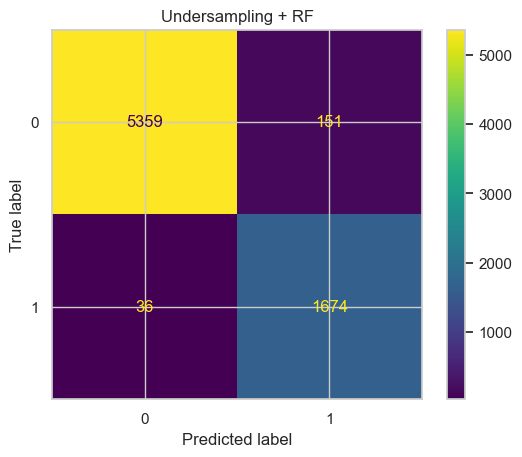

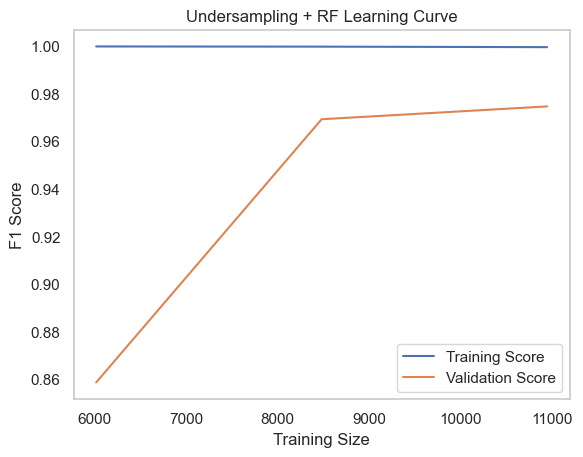

In [104]:
model_rf_under = RandomForestClassifier()
model_rf_under.fit(X_train_under, y_train_under)

evaluate_model(model_rf_under, X_test_tfidf, y_test, "Undersampling + RF")
plot_learning_curve(model_rf_under, X_train_under, y_train_under, "Undersampling + RF Learning Curve")

=== Undersampling + SVM ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      5510
           1       0.97      0.98      0.98      1710

    accuracy                           0.99      7220
   macro avg       0.98      0.99      0.99      7220
weighted avg       0.99      0.99      0.99      7220



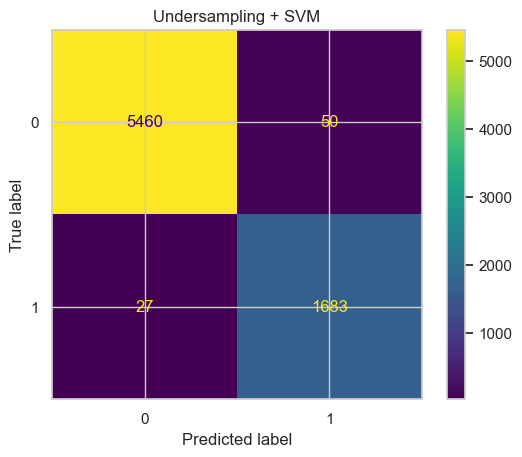

c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\env\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\env\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\OneDrive\Documents\Kuliah CS\SKRIPSI\judol\github\env\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\OneDrive\Documents\Kuliah 

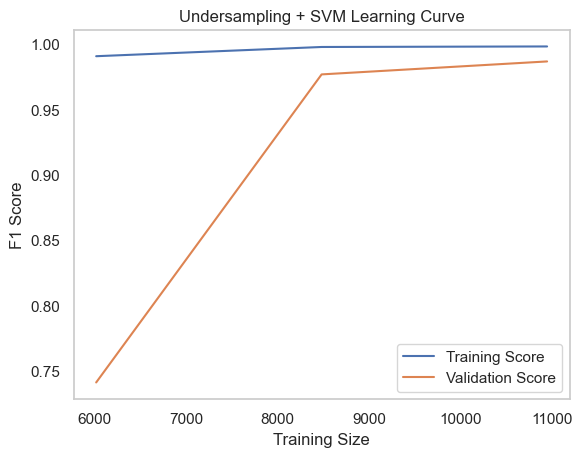

In [105]:
model_svm_under = SVC()
model_svm_under.fit(X_train_under, y_train_under)

evaluate_model(model_svm_under, X_test_tfidf, y_test, "Undersampling + SVM")
plot_learning_curve(model_svm_under, X_train_under, y_train_under, "Undersampling + SVM Learning Curve")

## SKENARIO 4 - TF-IDF VARIATION (BIGRAM)

=== Bigram - LR ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5510
           1       0.98      0.94      0.96      1710

    accuracy                           0.98      7220
   macro avg       0.98      0.97      0.97      7220
weighted avg       0.98      0.98      0.98      7220



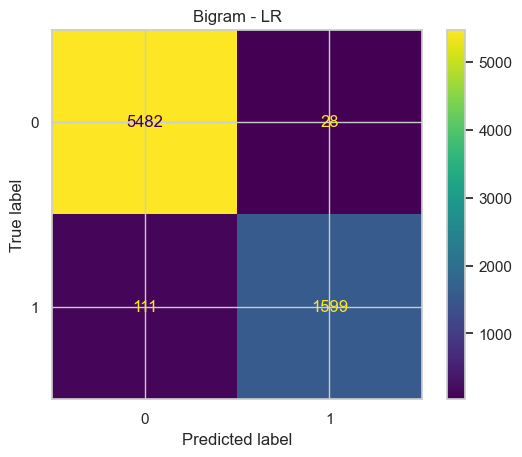

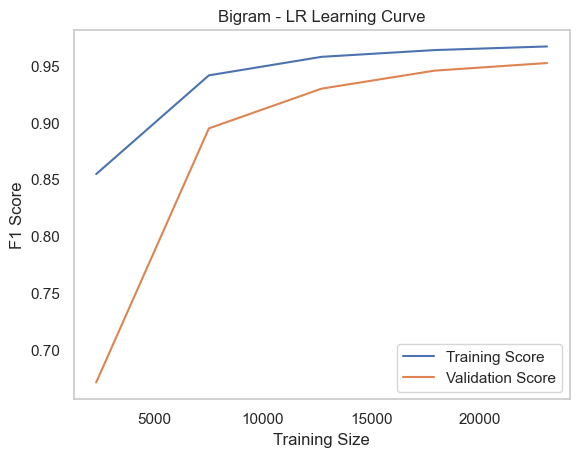

In [106]:
X_train_bigram, X_test_bigram = tfidf_transform(
    X_train, X_test, max_features=5000, ngram_range=(1,2)
)

model_lr_bigram = LogisticRegression(max_iter=1000)
model_lr_bigram.fit(X_train_bigram, y_train)

evaluate_model(model_lr_bigram, X_test_bigram, y_test, "Bigram - LR")
plot_learning_curve(model_lr_bigram, X_train_bigram, y_train, "Bigram - LR Learning Curve")

=== Bigram - RF ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5510
           1       0.98      0.96      0.97      1710

    accuracy                           0.99      7220
   macro avg       0.99      0.98      0.98      7220
weighted avg       0.99      0.99      0.99      7220



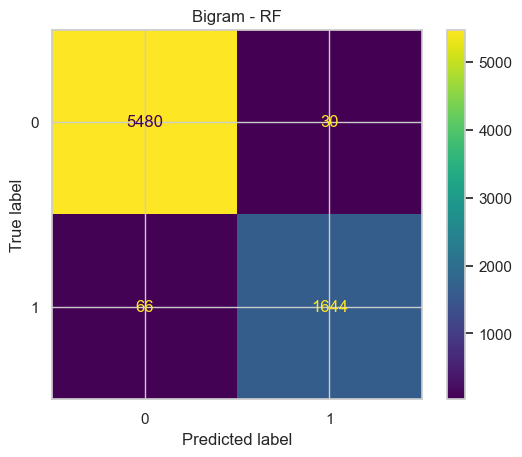

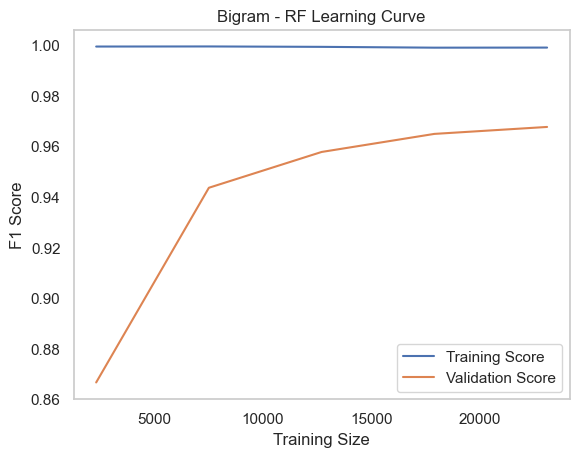

In [107]:
model_rf_bigram = RandomForestClassifier()
model_rf_bigram.fit(X_train_bigram, y_train)

evaluate_model(model_rf_bigram, X_test_bigram, y_test, "Bigram - RF")
plot_learning_curve(model_rf_bigram, X_train_bigram, y_train, "Bigram - RF Learning Curve")


=== Bigram - SVM ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5510
           1       0.99      0.97      0.98      1710

    accuracy                           0.99      7220
   macro avg       0.99      0.98      0.99      7220
weighted avg       0.99      0.99      0.99      7220



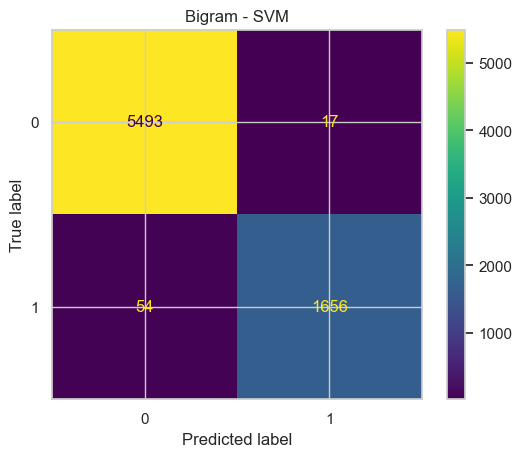

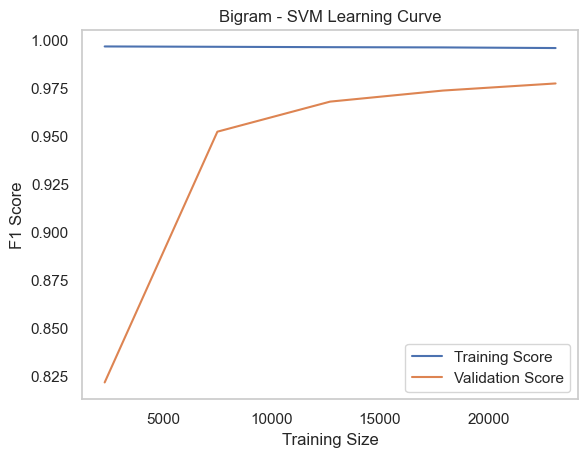

In [108]:
model_svm_bigram = SVC()
model_svm_bigram.fit(X_train_bigram, y_train)

evaluate_model(model_svm_bigram, X_test_bigram, y_test, "Bigram - SVM")
plot_learning_curve(model_svm_bigram, X_train_bigram, y_train, "Bigram - SVM Learning Curve")

## SKENARIO 5 - HYPERPARAMETER TUNING

**Logistic Regression**

Best LR: {'C': 10}
=== Tuned LR ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5510
           1       0.99      0.97      0.98      1710

    accuracy                           0.99      7220
   macro avg       0.99      0.98      0.99      7220
weighted avg       0.99      0.99      0.99      7220



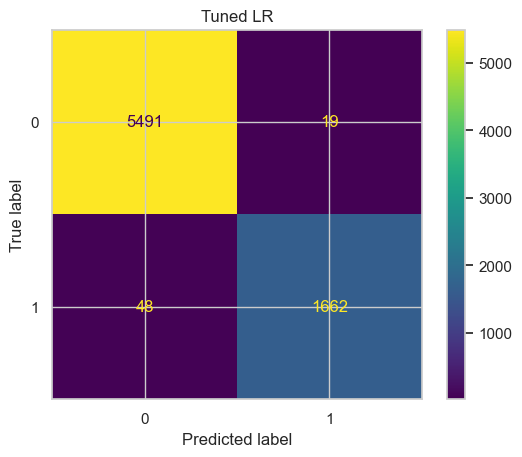

In [109]:
param_lr = {
    'C': [0.1, 1, 10]
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_lr, cv=5, scoring='f1')
grid_lr.fit(X_train_tfidf, y_train)

print("Best LR:", grid_lr.best_params_)

best_lr = grid_lr.best_estimator_
evaluate_model(best_lr, X_test_tfidf, y_test, "Tuned LR")

**RF**

Best RF: {'max_depth': None, 'n_estimators': 200}
=== Tuned RF ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5510
           1       0.98      0.97      0.97      1710

    accuracy                           0.99      7220
   macro avg       0.99      0.98      0.98      7220
weighted avg       0.99      0.99      0.99      7220



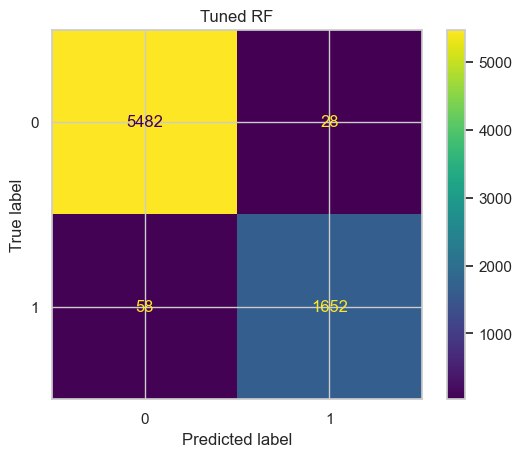

In [110]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_rf, cv=5, scoring='f1')
grid_rf.fit(X_train_tfidf, y_train)

print("Best RF:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
evaluate_model(best_rf, X_test_tfidf, y_test, "Tuned RF")

**SVM**

Best SVM: {'C': 10, 'kernel': 'rbf'}
=== Tuned SVM ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5510
           1       0.99      0.97      0.98      1710

    accuracy                           0.99      7220
   macro avg       0.99      0.99      0.99      7220
weighted avg       0.99      0.99      0.99      7220



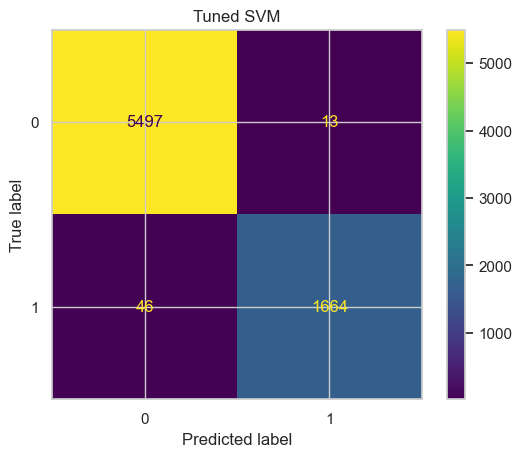

In [111]:
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(SVC(), param_svm, cv=5, scoring='f1')
grid_svm.fit(X_train_tfidf, y_train)

print("Best SVM:", grid_svm.best_params_)

best_svm = grid_svm.best_estimator_
evaluate_model(best_svm, X_test_tfidf, y_test, "Tuned SVM")

## Perbandingan Hasil Evaluasi Model

In [112]:
from numpy import add


results = []

def add_result(name, model, X_test, y_test):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

# Tambahkan hasil
add_result("Baseline LR", model_lr, X_test_tfidf, y_test)
add_result("SMOTE + LR", model_lr_smote, X_test_tfidf, y_test)
add_result("SMOTE + SVM", model_svm_smote, X_test_tfidf, y_test)
add_result("SMOTE + RF", model_rf_smote, X_test_tfidf, y_test)
add_result("Underfitting + LR", model_lr_under, X_test_tfidf, y_test)
add_result("Underfitting + RF", model_rf_under, X_test_tfidf, y_test)
add_result("Underfitting + SVM", model_svm_under, X_test_tfidf, y_test)
add_result("Bigram LR", model_lr_bigram, X_test_bigram, y_test)
add_result("Bigram RF", model_rf_bigram, X_test_bigram, y_test)
add_result("Bigram SVM", model_svm_bigram, X_test_bigram, y_test)
add_result("Tuned LR", best_lr, X_test_tfidf, y_test)
add_result("Tuned RF", best_rf, X_test_tfidf, y_test)
add_result("Tuned SVM", best_svm, X_test_tfidf, y_test)

df_results = pd.DataFrame(results)
df_results

,Model,Accuracy,Precision,Recall,F1
0,Baseline LR,0.980886,0.982801,0.935673,0.958658
1,SMOTE + LR,0.979224,0.933333,0.982456,0.957265
2,SMOTE + SVM,0.951108,0.844242,0.973099,0.904102
3,SMOTE + RF,0.983518,0.965477,0.964912,0.965195
4,Underfitting + LR,0.980194,0.945931,0.971930,0.958754
5,Underfitting + RF,0.974100,0.917260,0.978947,0.947100
6,Underfitting + SVM,0.989335,0.971148,0.984211,0.977636
7,Bigram LR,0.980748,0.982790,0.935088,0.958346
8,Bigram RF,0.986704,0.982079,0.961404,0.971631
9,Bigram SVM,0.990166,0.989839,0.968421,0.979013


## Visualisasi Perbandingan

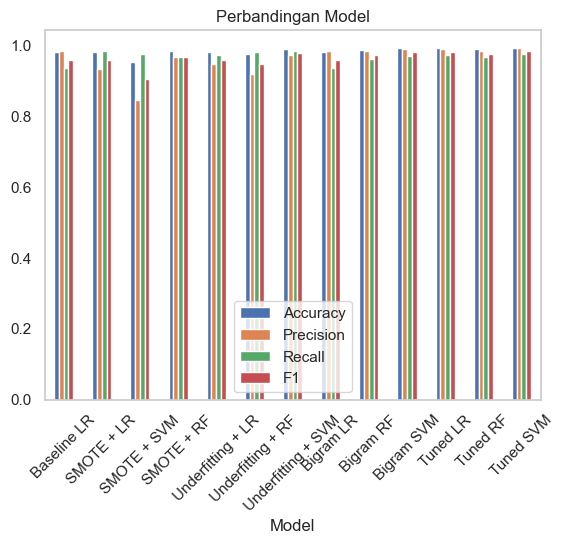

In [113]:
df_results.set_index("Model")[["Accuracy","Precision","Recall","F1"]].plot(kind="bar")
plt.title("Perbandingan Model")
plt.xticks(rotation=45)
plt.grid()
plt.show()